#Загрузка данных. Выводы по качеству данных

##Загрузка данных в датасет

In [ ]:
# инсталляция библиотеки яндекс диска
!pip -q install yadisk==2.1.0

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.4/91.4 kB 1.2 MB/s eta 0:00:00


In [ ]:
# инсталляция библиотеки profiling
!pip -q install ydata_profiling

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 359.5/359.5 kB 7.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.8/104.8 kB 6.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 686.1/686.1 kB 12.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.5/296.5 kB 10.4 MB/s eta 0:00:00


In [ ]:
# инсталляция бибилотеки squarify
!pip -q install squarify

In [ ]:
# импорт необходимых библиотек
import yadisk
import os
import sys
from tqdm import tqdm
import pandas as pd
import scipy.stats as stats
import numpy as np
import datetime as dt
import seaborn as sns
import squarify
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import plotly.express as px
from ydata_profiling import ProfileReport
import warnings
warnings.filterwarnings("ignore")

In [ ]:
# загрузка переменных среды для яндекс диск
app_id = '3a7bf81215c04f85842decdd113ec817'
secret_id = 'fa580b0d887c4065b2879d0074362da9'
ya_token = 'y0_AgAAAABo3h-bAAvILgAAAAEE0pVkAACJdaxsZnBEs5IOgruh5LopLffobQ'

In [ ]:
# подключение к яндекс диску
y = yadisk.YaDisk(app_id, secret_id, ya_token)

In [ ]:
# проверка подключения через валидность токена
if y.check_token():
    print('Token correct')

Token correct


In [ ]:
# создание списка файлов для загрузки
list_of_files = []
for el in tqdm(list(y.listdir('auto'))):
    if el['path'].endswith('.csv'):
        list_of_files.append(el['path'])
list_of_files

100%|██████████| 1/1 [00:00<00:00, 7516.67it/s]


['disk:/auto/kz_2019_final_all_dirt.csv']

In [ ]:
# создание папки для загрузки файлов из яндекс диска
load_path = '/content/ya/'
if not os.path.exists(load_path):
    os.mkdir(load_path)
os.chdir(load_path)

In [ ]:
# скачивание файлов из яндекс диска в коллаб
for file in tqdm(list_of_files):
    y.download(file.split(':')[1], file.split('/')[-1])

100%|██████████| 1/1 [00:04<00:00,  4.54s/it]


In [ ]:
# проверка корректности загрузки
os.listdir()

['kz_2019_final_all_dirt.csv']

In [ ]:
# загрузка скаченного файла в датасет
auto = pd.read_csv('kz_2019_final_all_dirt.csv', sep=',')

*Первичная оценка данных, содержащихся в датасете auto*

In [ ]:
# общий вид имеющихся данных
auto.sample()

,Unnamed: 0,Год,Месяц,Компания,Бренд,Модель,Модификация,Год выпуска,Страна-производитель,Вид топлива,...,Тип клиента,Форма расчета,Количество,"Цена, USD","Продажа, USD",Область,Сегментация 2013,Класс 2013,Сегментация Eng,Локализация производства
30182,30182,2019,Сентябрь,Toyota Motor Kazakhstan,Toyota,RAV4,91,2018,Российская Федерация,Бензин,...,Физ. Лицо,NaN,1.0,32935.813335,32935.813335,г.Алматы,Внедорожники,Среднеразмерные SUV,K1,Импорт


In [ ]:
# размер датасета и тип данных в нем
auto.info()
print('Исходное состояние DataFrame', auto.shape)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32854 entries, 0 to 32853
Data columns (total 26 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Unnamed: 0                      32854 non-null  int64  
 1   Год                             32854 non-null  int64  
 2   Месяц                           32854 non-null  object 
 3   Компания                        32854 non-null  object 
 4   Бренд                           32854 non-null  object 
 5   Модель                          32854 non-null  object 
 6   Модификация                     29729 non-null  object 
 7   Год выпуска                     32700 non-null  object 
 8   Страна-производитель            32854 non-null  object 
 9   Вид топлива                     31942 non-null  object 
 10  Объём двиг, л,                  30968 non-null  object 
 11  Коробка передач                 31662 non-null  object 
 12  Тип привода                     

In [ ]:
# определим картину по пропускам (%)
auto.isna().sum()/auto.shape[0]*100

Unnamed: 0                         0.000000
Год                                0.000000
Месяц                              0.000000
Компания                           0.000000
Бренд                              0.000000
Модель                             0.000000
Модификация                        9.511779
Год выпуска                        0.468740
Страна-производитель               0.000000
Вид топлива                        2.775918
Объём двиг, л,                     5.740549
Коробка передач                    3.628173
Тип привода                        6.894138
Сегмент                           14.573568
Регион                             0.000000
Наименование дилерского центра     0.000000
Тип клиента                       17.440799
Форма расчета                     78.453156
Количество                         0.015219
Цена, USD                          0.000000
Продажа, USD                       0.000000
Область                            0.000000
Сегментация 2013                

In [ ]:
# определим картину по явным дубликатам
auto.duplicated().sum()

0

##Выводы

* опираясь на поверхностную оценку, первоначально решено преобразовать в данных следующее:
  * названия полей переименовать с использованием латинского алфавита ("змеиный" стиль)
  * на основе столбцов "Год", "Месяц" решено создать дополнительный "order_date", содержащий дату (год и месяц) продажи, в поле "Год выпуска" заменить тип данных на datetime, а в поле "Количество" на int, так как они более предпочтительны
  * поля "Unnamed: 0", Модификация", "Сегмент", "Наименование дилерского центра", "Тип клиента", "Форма расчета", "Сегментация Eng" и "Локализация производства" можно удалить по причине отсутствия необходимости использования в анализе, а так же дублирования информации других полей
  * в значительном количестве были обнаружены пропуски в полях "Модификация" (9.5%), "Вид топлива" (2.7%), "Объем двигателя" (5.7%), "Коробка передач" (3.6%), "Тип привода" (6.8%), "Сегмент" (14.5%), "Тип клиента" (17%) и "Форма расчета" (78%). Большинство из перечисленных полей в следствии ненадобности было решено удалить. Пропуски в полях "Вид топлива" и "Объем двигателя" решено заполнить значением моды по модели автомобиля
  * явные дубликаты в данных обнаружены не были
  * на этапе предобработки необходимо дополнительно проверить данные, содержащиеся в полях на корректность и единообразие

#Предобработка данных

##Переименование полей. Удаление ненужных полей

In [ ]:
# изначально удалим вышеупомянутые столбцы
auto = auto.drop(["Unnamed: 0", "Модификация", "Сегмент", "Наименование дилерского центра",
                  "Тип клиента", "Форма расчета", "Сегментация Eng",
                  "Локализация производства"], axis=1)

In [ ]:
auto.columns

Index(['Год', 'Месяц', 'Компания', 'Бренд', 'Модель', 'Год выпуска',
       'Страна-производитель', 'Вид топлива', 'Объём двиг, л,',
       'Коробка передач', 'Тип привода', 'Регион', 'Количество', 'Цена, USD',
       'Продажа, USD', 'Область', 'Сегментация 2013', 'Класс 2013'],
      dtype='object')

In [ ]:
# создадим списки со старыми и новыми названиями столбцов
old_cols = auto.columns.tolist()
new_cols = ['year_sell', 'month_sell', 'company', 'brand_auto',
            'model_auto', 'year_prod', 'country_prod', 'petrol',
            'engine', 'gearbox', 'type_drive', 'region', 'count_auto',
            'price', 'final_price', 'state', 'segment', 'class_2013']

In [ ]:
# перезапишем названия столбцов
change_cols_dict = dict(zip(old_cols, new_cols))
auto = auto.rename(columns=change_cols_dict)

In [ ]:
# проверим результат преобразования
auto.columns

Index(['year_sell', 'month_sell', 'company', 'brand_auto', 'model_auto',
       'year_prod', 'country_prod', 'petrol', 'engine', 'gearbox',
       'type_drive', 'region', 'count_auto', 'price', 'final_price', 'state',
       'segment', 'class_2013'],
      dtype='object')

##Замена типов данных

In [ ]:
# проверим, какие данные содержатся в полях "year_sell", "month_sell"
auto.month_sell.unique()

array(['Март', 'Май', 'Июнь', 'Июль', 'Январь', 'Февраль', 'Апрель',
       'Август', 'Сентябрь'], dtype=object)

In [ ]:
auto.year_sell.unique()

array([2019])

*В поле с месяцем продажи, месяц указан текстом. Зададим новый столбец order_date, содержащий год и месяц продажи*

In [ ]:
# изначально заменим названия месяцев в поле "month_sell" на порядковый номер
months = {'Январь':'1', 'Февраль':'2', 'Март':'3', 'Апрель':'4', 'Май':'5',
          'Июнь':'6', 'Июль':'7', 'Август':'8', 'Сентябрь':'9'} # создадим словарь

In [ ]:
# заменим на циферные обозначения названия месяцев
auto.month_sell = auto.month_sell.map(months)
auto.month_sell.unique()

array(['3', '5', '6', '7', '1', '2', '4', '8', '9'], dtype=object)

In [ ]:
# теперь создадим дополнительное поле и выведем результат
auto['order_date'] = pd.to_datetime(auto.year_sell.astype('str') + '/' + auto.month_sell + '/01')

In [ ]:
auto.order_date.sample()

22718   2019-06-01
Name: order_date, dtype: datetime64[ns]

In [ ]:
# посмотрим на данные в поле "year_prod" более пристально
auto.year_prod.unique()

array(['2017', '2018', '2016', '2011', '2015', nan, '2014', '2013',
       '2012', '2\xa0018', '2\xa0017', '2\xa0016', 2018, 2017, 2015, 2016],
      dtype=object)

*Как мы можем наблюдать, имеется несколько искаженных обозначний года производста. Заменим эти данные на более корректные, а затем преобразуем тип данных*

In [ ]:
auto.year_prod = auto.year_prod.replace({'2\xa0016':'2016', '2\xa0017':'2017', '2\xa0018':'2018'})
auto.year_prod.unique() # результат

array(['2017', '2018', '2016', '2011', '2015', nan, '2014', '2013',
       '2012', 2018, 2017, 2015, 2016], dtype=object)

In [ ]:
# заменим тип данных в поле "year_prod" на datetime
auto.year_prod = pd.to_datetime(auto.year_prod, format='%Y')

In [ ]:
# заменим тип данных в поле "count" на int
auto.count_auto = auto.count_auto.astype('Int32')

In [ ]:
# проверим итоги преобразования типов данных
auto.dtypes

year_sell                int64
month_sell              object
company                 object
brand_auto              object
model_auto              object
year_prod       datetime64[ns]
country_prod            object
petrol                  object
engine                  object
gearbox                 object
type_drive              object
region                  object
count_auto               Int32
price                  float64
final_price            float64
state                   object
segment                 object
class_2013              object
order_date      datetime64[ns]
dtype: object

##Проверка данных на корректные значения. Поиск аномальных значений. Замена пропусков

In [ ]:
# проверим поле "company" на корректность содержащихся данных
auto.company.unique()

array(['Mercur Auto', 'Автоцентр-Бавария', 'БИПЭК АВТО', 'Вираж',
       'Sivi Finance Consulting', 'Eurasia Motor Premium',
       'Daewoo Bus Kazakhstan', 'Caspian Motors', 'Каспиан Моторс',
       'СемАЗ', 'ТК Рос-Авто', 'Astana Motors',
       'Hyundai Com Trans Kazakhstan ', 'Nissan Manufacturing RUS', 'СВС',
       'СВС-ТРАНС', 'Allur Auto', 'Jaguar Land Rover', 'ТК КАМАЗ',
       'Toyota Motor Kazakhstan', 'Лифан Моторс Рус',
       'MAN Truck & Bus Kazakhstan', 'Автомир ГК', 'Autokapital',
       'MMC RUS', 'ММС Рус', 'УзАвто-Казахстан', 'Алматы АТО',
       'Renault Россия', 'Scania Central Asia', 'Subaru Kazakhstan',
       'SMC', 'Scandinavian Motors', 'Хино Моторс Казахстан',
       'Hino Motors Kazakhstan'], dtype=object)

*Стоит обратить внимание на дублирование наименований некоторых компаний посредством киррилической и латинской раскладок. А именно "Caspian Motors" и "Каспиан Моторс", "MMC RUS" и "ММС Рус", "Хино Моторс Казахстан" и "Hino Motors Kazakhstan". Также в названии "Hyundai Com Trans Kazakhstan" обнаружен лишний пробел, который тоже для порядка решено устранить*

In [ ]:
# первоначально приведем все записи в поле "company" к единому регистру и удалим пробелы
auto.company = auto.company.str.capitalize().str.strip()

In [ ]:
# исключим подобные дублирования, заменив киррилическую раскладку на латинскую
auto.company = auto.company.replace(['Каспиан mоторс', 'Ммс рус', 'Хино моторс казахстан'],
                                    ['Caspian мotors', 'Mmc rus', 'Hino motors kazakhstan'])

In [ ]:
# оценим результат замены
auto.company.unique()

array(['Mercur auto', 'Автоцентр-бавария', 'Бипэк авто', 'Вираж',
       'Sivi finance consulting', 'Eurasia motor premium',
       'Daewoo bus kazakhstan', 'Caspian motors', 'Каспиан моторс',
       'Семаз', 'Тк рос-авто', 'Astana motors',
       'Hyundai com trans kazakhstan', 'Nissan manufacturing rus', 'Свс',
       'Свс-транс', 'Allur auto', 'Jaguar land rover', 'Тк камаз',
       'Toyota motor kazakhstan', 'Лифан моторс рус',
       'Man truck & bus kazakhstan', 'Автомир гк', 'Autokapital',
       'Mmc rus', 'Узавто-казахстан', 'Алматы ато', 'Renault россия',
       'Scania central asia', 'Subaru kazakhstan', 'Smc',
       'Scandinavian motors', 'Hino motors kazakhstan'], dtype=object)

In [ ]:
# аналогично проверим поле "brand_auto" на корректность содержащихся данных
auto.brand_auto.unique()

array(['Audi', 'BMW', 'Chevrolet', 'Daewoo', 'Ford', 'Foton', 'GAZ',
       'Hyundai', 'Hyundai Truck & Bus', 'Infiniti', 'Isuzu', 'Iveco',
       'Jac', 'Jaguar', 'KAMAZ', 'Kia', 'Lada', 'Land Rover', 'Lexus',
       'Lifan', 'MAN', 'Mazda', 'Mercedes-Benz', 'Mercedes-Benz Trucks',
       'Mini', 'Mitsubishi', 'Nissan', 'Peugeot', 'Porsche', 'Ravon',
       'Renault', 'Scania', 'Shacman', 'Skoda', 'SsangYong', 'Subaru',
       'Suzuki', 'Toyota', 'UAZ', 'Volkswagen', 'Volvo', 'Урал', 'МАЗ',
       'Cadillac', 'ANKAI', 'Hino', 'Rolls Royce'], dtype=object)

*Проблем в поле, содержащим бренд авто обнаружено не было*

In [ ]:
# аналогично проверим поле "model_auto" на корректность содержащихся данных
auto.model_auto.unique()

array(['A3', 'A4', 'A5', 'A6', 'A7', 'A8', 'Q5', 'Q7', '1 серия',
       '2 серия', '3 серия', '4 серия', '5 серия', '6 серия', '7 серия',
       'i3', 'X1', 'X3', 'X4', 'X5', 'X6', 'Aveo', 'Captiva', 'Niva',
       'Tahoe', 'Tracker', 'BS 106 A', 'EcoSport', 'Explorer', 'Fiesta',
       'Focus', 'Kuga', 'Mondeo', 'Transit', 'Transit Custom',
       'BJ1032V3JB3-S', 'BJ3143DKPGA-1', 'BJ3253DMPKB-AD',
       'BJ5032V3BB3-S', 'BJ5163VKCHN-1', '2217', '2310', '2705', '2752',
       '3221', '3302', '3308', '3309', 'Next', 'Accent', 'Creta',
       'Elantra', 'Genesis G90', 'Grandeur', 'Santa Fe', 'Sonata',
       'TQ-1/H-1', 'County', 'H350', 'HD 160', 'HD 170', 'HD 260',
       'HD 65', 'HD 72', 'HD 78', 'Universe', 'Tucson', 'Q30', 'Q50',
       'QX30', 'QX50', 'QX60', 'QX70', 'QX80', 'D-MAX', 'FVR34', 'NMR',
       'NPR', 'NQR71', 'Daily', 'Daily A', 'Daily V', 'Stralis', 'Tipper',
       'S3', 'S5', 'F-Pace', 'XE', 'XF', '4308', '43114', '43118',
       '43253', '43502', '44108', '4514

*Явных ошибок в поле "model_auto" обнаружено не было*

In [ ]:
# аналогично проанализируем поле "country_prod" на наличие некорректных данных
auto.country_prod.unique()

array(['Германия', 'США', 'Республика Казахстан', 'Российская Федерация',
       'Белоруссия', 'Турция', 'Япония', 'Корея', 'Вьетнам', 'UK',
       'Таиланд', 'Узбекистан', 'Венгрия', 'Австрия', 'Нидерланды',
       'Швеция'], dtype=object)

*В поле "country_prod" так же ошибок обнаружено не было. Для удобства закодируем в alpha3 названия стран (используем скаченную таблицу кодов)*

In [ ]:
# первоначально скачаем таблицу, содержащую коды стран
countr_list = pd.read_table('https://www.artlebedev.ru/country-list/tab/', encoding='utf8')
countr_list.columns

Index(['name', 'fullname', 'english', 'alpha2', 'alpha3', 'iso', 'location',
       'location-precise'],
      dtype='object')

In [ ]:
# создадим словари, содержащие как ключ полное название страны и как значение, ее код
full_c = {x: y for x, y in zip(countr_list['fullname'], countr_list['alpha3'])}
short_c = {x: y for x, y in zip(countr_list['name'], countr_list['alpha3'])}

In [ ]:
# преобразуем поле "country_prod"
auto.country_prod = auto.country_prod.apply(lambda cell: full_c.get(cell, cell))

In [ ]:
# дополнительно проделаем то же самое с другим словарем
auto.country_prod = auto.country_prod.apply(lambda cell: short_c.get(cell, cell))

In [ ]:
# повторно проанализируем поле "country_prod"
auto.country_prod.unique()

array(['DEU', 'США', 'KAZ', 'RUS', 'Белоруссия', 'TUR', 'JPN', 'Корея',
       'VNM', 'UK', 'THA', 'UZB', 'HUN', 'AUT', 'NLD', 'SWE'],
      dtype=object)

In [ ]:
# посмотрим на данные в поле "petrol" более пристально
auto.petrol.unique()

array(['Бензин', 'Дизель', 'гибрид', 'Электрический', nan, '0', 'дизель ',
       'Газовый'], dtype=object)

*В поле "petrol" необходимо привести данные к единому стилю (нижний регистр, исключение лишних пробелов), посмотреть на модели автомобилей, информация о которых отсутствует или внесен 0. Данные пропуски можно заполнить к примеру модой по модели автомобиля. По итогу оставим "бензин", "дизель", "гибрид", "электро" и "газовый"*

In [ ]:
# приведем данные к нижнему регистру и исключим лишние пробелы
auto.petrol = auto.petrol.str.lower().str.strip()

In [ ]:
# заменим "электрический" и "газовый" на более короткие наименования
auto.petrol = auto.petrol.replace({'электрический':'электро', 'газовый':'газ'})

*Более детально изучим модели автомобилей, данные о которых внесены не были*

In [ ]:
# посмотрим на модели, данные о которых имеют пропуски в поле "petrol"
no_petrol = auto[auto.petrol.isna()]['model_auto'].unique().tolist()
print('Всего моделей автомобилей с пропусками в поле "petrol"', len(no_petrol))

Всего моделей автомобилей с пропусками в поле "petrol" 53


*Заполним пропущенные данные в поле "petrol" вышеперечисленных моделей  наиболее популярным типом топлива среди них*

In [ ]:
# первоначально определим наиболее популярный тип топлива той или иной модели
auto.query('model_auto in @no_petrol').groupby('model_auto')['petrol'].value_counts().sort_values(ascending=False)

model_auto          petrol
Duster              бензин    472
Polo                бензин    459
RX                  бензин    330
Sandero             бензин    193
D-MAX               дизель    131
Tiguan              бензин    111
Logan               бензин     97
Jetta               бензин     93
3741                бензин     47
Kaptur              бензин     40
Range Rover         бензин     35
NMR                 дизель     23
CX-5                бензин     22
Range Rover Sport   бензин     17
Cargo               бензин     15
NPR                 дизель     13
Range Rover Velar   бензин     12
QX50                бензин     11
6                   бензин     11
Passat B8           бензин     10
LS                  бензин     10
Discovery           бензин      5
Universe            дизель      5
4x4 Pickup          бензин      4
Touareg             бензин      3
                    дизель      3
Koleos              0           2
F-Pace              бензин      2
Q30                 б

In [ ]:
# предварительно взглянем на авто, у которых в поле "petrol" указано значение "0"
auto[auto['petrol'] == '0'][['brand_auto', 'model_auto']]

,brand_auto,model_auto
19519,Renault,Kaptur
19732,Renault,Koleos
19733,Renault,Koleos
19953,Renault,Sandero


*Как мы можем видеть, автомобилей со значением "0" в поле "petrol" всего 4 и это автомобили бренда "Renault" моделей "Kaptur", "Koleos" и "Sandero". Заменим эти значения в поле "petrol" на "nan"*

In [ ]:
auto.petrol = auto.petrol.replace('0', np.nan)

In [ ]:
# взглянем как прошла замена
auto.petrol.unique()

array(['бензин', 'дизель', 'гибрид', 'электро', nan, 'газ'], dtype=object)

In [ ]:
# посмотрим на то, сколько теперь имеется пропусков в поле "petrol"
print('Пропущенных значений в поле "petrol" после замены', round(auto.petrol.isna().sum()/auto.shape[0]*100, 2), '%')

Пропущенных значений в поле "petrol" после замены 2.79 %


In [ ]:
# теперь заполним все пропуска значением моды по модели автомобиля
auto['petrol'] = auto.groupby('model_auto')['petrol']\
.transform(lambda x: x.fillna(x.mode()[0] if not x.mode().empty else "unknown")) # а для моделей, где вовсе не указан тип топлива, внесем "unknown"

In [ ]:
# повторно проанализируем состояние данных в поле "petrol"
auto.petrol.unique()

array(['бензин', 'дизель', 'гибрид', 'электро', 'unknown', 'газ'],
      dtype=object)

In [ ]:
# определим теперь процент недостающих записей в поле "petrol" после всех преобразований
print('В результате обработки поля "petrol" недостающих данных', round(len(auto.query('petrol == "unknown"'))/auto.shape[0]*100, 2), '%')

В результате обработки поля "petrol" недостающих данных 0.46 %


In [ ]:
# посмотрим на данные в поле "engine" более пристально
auto.engine.unique()

array(['1.4', '2', '3', '1.5', '4.4', '6.6', nan, '0', '1.8', '1.596',
       '1596', '2.4', '3000', '2400', '1.7', '6.2', '1800', '1400 turbo',
       '1,4 Turbo', '2.5', '1.6', '3.5', '2.2', '2.7', '2.8', '4.2', '5',
       '3.9', '7.5', '11', '3.933', '12.3', '1,6 T-GDI', '3.7', '5.6',
       '7.8', '2.9', '5.2', '10.3', '8.7', '1600', '1.998', '1.598',
       '1.248', '2.359', '2359', '1999', '3.8', '3800', '1.591', '1.368',
       '3.342', '3.47', '3470', '2000', '1.999', '1.69', '1690', '1.774',
       '1598', '1774', '4.9', '4.6', '3,5', '5.7', '10.5', '6.7', '2/2,5',
       '4', '5.5', '12', '1.2', '3.6', '6.5', '4.5', '1.25', '1.3',
       '0.002', '0.0016', '1998', '13', '16', '1400', '2.3', '1.33',
       '2,4G', '2.693', '2693', '2.235', '2235', '2.0', '14860', '14.8',
       '17.5', '1,2T', '4.88', 4.88, 4.0, 2.0, 6.6, 7.8, 2.8, 3.6],
      dtype=object)

*Среди данных в поле "engine" мы можем наблюдать в качестве дробного разделителя символ "," вместо предпочтительного ".", а также комбинации из букв и цифр, четырехзначные числа, вероятно введенные ошибочно. Заменим во всех данных дробный разделитель, а затем некорректные и пропущенные значения модой по модели автомобиля (аналогично столбцу с типом топлива). Также отдельно посмотрим на модели автомобилей, чей объем двигателя более 10*

In [ ]:
# предварительно преобразуем некорректные данные, для более удобной последующей замены
auto.engine = auto.engine.replace({'3,5':'3.5'})

In [ ]:
# зададим список, куда внесем все обнаруженные некорректные значения
mstk = ['0', '1596', '3000', '2400', '1800', '1400 turbo', '1,4 Turbo',
        '1,6 T-GDI', '1600', '2359', '1999', '3800', '3470', '2000',
        '1690', '1598', '1774', '2/2,5', '0.002', '0.0016', '1998',
        '1400', '2,4G', '2693', '2235', '14860', '1,2T']

In [ ]:
# теперь заменим вышеупомянутые значения на пропуски
auto.engine = auto.engine.replace(mstk, np.nan)

In [ ]:
# обозначим результат преобразований
auto.engine.unique()

array(['1.4', '2', '3', '1.5', '4.4', '6.6', nan, '1.8', '1.596', '2.4',
       '1.7', '6.2', '2.5', '1.6', '3.5', '2.2', '2.7', '2.8', '4.2', '5',
       '3.9', '7.5', '11', '3.933', '12.3', '3.7', '5.6', '7.8', '2.9',
       '5.2', '10.3', '8.7', '1.998', '1.598', '1.248', '2.359', '3.8',
       '1.591', '1.368', '3.342', '3.47', '1.999', '1.69', '1.774', '4.9',
       '4.6', '5.7', '10.5', '6.7', '4', '5.5', '12', '1.2', '3.6', '6.5',
       '4.5', '1.25', '1.3', '13', '16', '2.3', '1.33', '2.693', '2.235',
       '2.0', '14.8', '17.5', '4.88', 4.88, 4.0, 2.0, 6.6, 7.8, 2.8, 3.6],
      dtype=object)

In [ ]:
# теперь заменим все пропущенные значения модой по модели авто
auto.engine = auto.groupby('model_auto')['engine']\
.transform(lambda x: x.fillna(x.mode()[0] if not x.mode().empty else "0")) # а для моделей, где вовсе не указан объем двигателя, внесем значение "0"

In [ ]:
# повторно проверим поле "engine" на уникальные значения
auto.engine.unique()

array(['1.4', '2', '3', '1.5', '4.4', '6.6', '0', '1.8', '1.596', '2.4',
       '1.7', '6.2', '2.5', '1.6', '3.5', '2.2', '2.7', '2.8', '4.2', '5',
       '3.9', '7.5', '11', '3.933', '12.3', '3.7', '5.6', '7.8', '2.9',
       '5.2', '10.3', '8.7', '1.998', '1.598', '1.248', '2.359', '3.8',
       '1.591', '1.368', '3.342', '3.47', '1.999', '1.69', '1.774', '4.9',
       '4.6', '5.7', '10.5', '6.7', '4', '5.5', '12', '1.2', '3.6', '6.5',
       '4.5', '1.25', '1.3', '13', '16', '2.3', '1.33', '2.693', '2.235',
       '2.0', '17.5', '14.8', '4.88', 4.88, 4.0, 2.0, 6.6, 7.8, 2.8, 3.6],
      dtype=object)

In [ ]:
# и определим теперь процент недостающих записей в поле "engine" после всех преобразований
print('В результате обработки поля "engine" недостающих данных', round(len(auto.query('engine == "0"'))/auto.shape[0]*100, 2), '%')

В результате обработки поля "engine" недостающих данных 3.59 %


In [ ]:
# теперь посмотрим на авто, объем двигателя которых более 10
auto.engine = auto.engine.astype('float') # для этого для удобства поменяем тип данных на float

In [ ]:
# и выполним определенный срез
auto.query('engine > 10')['brand_auto'].unique()

array(['Hyundai Truck & Bus', 'Iveco', 'MAN', 'Mercedes-Benz Trucks',
       'Scania', 'МАЗ'], dtype=object)

*Бренды авто, чьи двигатели в объеме более 10Л на самом деле производят грузовую технику, следовательно данные в поле "engine" соответствуют действительности*

In [ ]:
# обратно заменим тип данных в поле "engine" так как это категориальная характеристика
auto.engine = auto.engine.astype('object')

In [ ]:
# взглянем более внимательно на столбец "gearbox"
auto.gearbox.unique()

array(['S-tronic', 'S-Тronic', 'S-Тroic', 'S-troic', 'Steptronic',
       'ТipТronic', 'Tiptronic', 'SТepТronic', 'Автомат', 'AT', '6 АТ',
       '5 МТ', '6AT', '5MT', '6АТ', '5МТ', 'MT', 'МТ', 'MТ', '6АT', '6MT',
       'Powershift S6', 'PowershiftS6', 'PowershifТS6', '6МТ', '6MТ', nan,
       'Мех.', 'МКПП', '6 AT', '6 MT', '8АТ', '5AT', '5АТ', '7DCT',
       '7 DCT', '7DCТ', 'АТ', 'CVT', 'N', 'CVT(вариатор)', 'CVТ', '6 МТ',
       '4АТ', '8 АТ', '8AT', '4 АТ', 'AMT', '4AT', 'АКПП6', 'АКПП4',
       '9AT', 'АКПП', 'АКПП8', 'МКПП4', 'МКПП5', 'CVT (вариатор)',
       'CVT(вариATор)', 'CVТ(вариатор)', '6AT/MT', '9АТ', '12AT', '7AT',
       '7АТ', '6М/Т', '6M/T', '6M/Т', '0', 'PDK', '8АКПП', '8-ступ АКПП',
       '8', ' -', '-', '7 DSG', '7DSG', '6 DSG', '6DSG', 'CVТ(вАриАтор)',
       '5MТ', 'АТ (автомат)', '8 AT 4Motion', '8АТ4МoТion', '6A', '5M',
       '6-ступАКПП', '6А', 'AT (автомат)', '7DSG4МoТion', '6Aвтомат',
       '6Aатомат', '5М', '5-ступМТ', 'АT', 'A/T', '7АT', 'МТ (механика

*Данные в поле "gearbox" необходимо привести к единообразию, оставив только два типа коробок передач - автоматическая (AT) и механическая (MT). Типы DSG, различные вариации "tronic" для удобства отнесем к автоматическому*

In [ ]:
# приведем все данные к единому стилю - нижний регистр и без лишних пробелов
auto.gearbox = auto.gearbox.str.lower().str.strip()
auto.gearbox.unique() # посмотрим на результат

array(['s-tronic', 's-тronic', 's-тroic', 's-troic', 'steptronic',
       'тipтronic', 'tiptronic', 'sтepтronic', 'автомат', 'at', '6 ат',
       '5 мт', '6at', '5mt', '6ат', '5мт', 'mt', 'мт', 'mт', '6аt', '6mt',
       'powershift s6', 'powershifts6', 'powershifтs6', '6мт', '6mт', nan,
       'мех.', 'мкпп', '6 at', '6 mt', '8ат', '5at', '5ат', '7dct',
       '7 dct', '7dcт', 'ат', 'cvt', 'n', 'cvt(вариатор)', 'cvт', '6 мт',
       '4ат', '8 ат', '8at', '4 ат', 'amt', '4at', 'акпп6', 'акпп4',
       '9at', 'акпп', 'акпп8', 'мкпп4', 'мкпп5', 'cvt (вариатор)',
       'cvt(вариatор)', 'cvт(вариатор)', '6at/mt', '9ат', '12at', '7at',
       '7ат', '6м/т', '6m/t', '6m/т', '0', 'pdk', '8акпп', '8-ступ акпп',
       '8', '-', '7 dsg', '7dsg', '6 dsg', '6dsg', '5mт', 'ат (автомат)',
       '8 at 4motion', '8ат4мoтion', '6a', '5m', '6-ступакпп', '6а',
       'at (автомат)', '7dsg4мoтion', '6aвтомат', '6aатомат', '5м',
       '5-ступмт', 'аt', 'a/t', '7аt', 'мт (механика)', 'механическая'],
  

In [ ]:
# приведем все значения в данном столбце к единообразию
def gear(row): # применив для этих целей функцию
  if 'mt' in str(row):
    return 'mt'
  elif 'мт' in str(row):
    return 'mt'
  elif 'мех' in str(row):
    return 'mt'
  elif 'мк' in str(row):
    return 'mt'
  elif 'm/t' in str(row):
    return 'mt'
  elif 'м/т' in str(row):
    return 'mt'
  else:
    return 'at'

In [ ]:
# применим написанную функцию к столбцу "gearbox"
auto.gearbox = auto.gearbox.apply(gear)

In [ ]:
# взглянем на результат преобразований
auto.gearbox.unique()

array(['at', 'mt'], dtype=object)

In [ ]:
# взглянем более детально на данные в столбце "type_drive"
auto.type_drive.unique()

array([nan, 'FWD', 'передний', 'quattro', 'Quattro', 'RWD', '4WD',
       'Полный', 'Задний', 'AWD', 'Передний', '4х2.2', 'Полный ',
       'задний', '2WD', '2 WD', '4 WD', '4х4', '4х2', '4x2', 'FR',
       '2WD/4WD', '2х4', '4x4', 'CVT', '0', ' -', '-', 'P/TIME', 'FF',
       'полный', '4Motion', 'передний '], dtype=object)

*Аналогично полю с типами коробок передач отсутствует единообразие. Распределим все данные на четыре типа привода - передний (FWD), задний (RWD), полный (4WD) и остальные с приводом на два колеса (2WD)*

In [ ]:
# приведем все данные к единому стилю - нижний регистр и без лишних пробелов
auto.type_drive = auto.type_drive.str.lower().str.replace(' ', '')

In [ ]:
# посмотрим на результат
auto.type_drive.unique()

array([nan, 'fwd', 'передний', 'quattro', 'rwd', '4wd', 'полный',
       'задний', 'awd', '4х2.2', '2wd', '4х4', '4х2', '4x2', 'fr',
       '2wd/4wd', '2х4', '4x4', 'cvt', '0', '-', 'p/time', 'ff',
       '4motion'], dtype=object)

In [ ]:
# аналогично приведем все значения в поле "type_drive" к единообразию
def drive(row): # применив функцию
  if 'передний' in str(row):
    return 'fwd'
  elif 'quattro' in str(row):
    return '4wd'
  elif 'полный' in str(row):
    return '4wd'
  elif 'задний' in str(row):
    return 'rwd'
  elif 'awd' in str(row):
    return '4wd'
  elif '4x4' in str(row):
    return '4wd'
  elif '4х4' in str(row):
    return '4wd'
  elif 'fr' in str(row):
    return 'fwd'
  elif 'ff' in str(row):
    return 'fwd'
  elif '4motion' in str(row):
    return '4wd'
  else:
    return '2wd'

In [ ]:
# применим написанную функцию к столбцу
auto.type_drive = auto.type_drive.apply(drive)

In [ ]:
# и взглянем на результат
auto.type_drive.unique()

array(['2wd', 'fwd', '4wd', 'rwd'], dtype=object)

In [ ]:
# взглянем на поле "region" более пристально
auto.region.unique()

array(['Алматы', 'Костанай', 'Атырау', 'Астана', 'Уральск',
       'Усть-Каменогорск', 'Петропавловск', 'Павлодар', 'Кокшетау',
       'Актау', 'Семей', 'Караганда', 'Актобе', 'Шымкент', 'Талдыкорган',
       'Кызылорда', 'Экибастуз', 'Рудный', 'Тараз', 'Аксай', 'Щучинск',
       'ЭКСПОРТ', 'Риддер', 'Шемонаиха'], dtype=object)

*В поле "region" некорректных или ошибочных данных обнаружено не было, но приведем все к единому регистру*

In [ ]:
# приведем все записи в поле "region" к единому регистру и удалим пробелы
auto.region = auto.region.str.capitalize()

In [ ]:
# проверим результат обработки
auto.region.unique()

array(['Алматы', 'Костанай', 'Атырау', 'Астана', 'Уральск',
       'Усть-каменогорск', 'Петропавловск', 'Павлодар', 'Кокшетау',
       'Актау', 'Семей', 'Караганда', 'Актобе', 'Шымкент', 'Талдыкорган',
       'Кызылорда', 'Экибастуз', 'Рудный', 'Тараз', 'Аксай', 'Щучинск',
       'Экспорт', 'Риддер', 'Шемонаиха'], dtype=object)

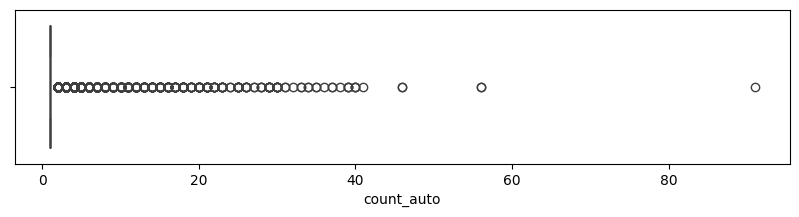

In [ ]:
# оценим столбец "count_auto" на наличие некорректных данных (выбросов)
plt.figure(figsize=(10, 2))
sns.boxplot(x=auto.count_auto, notch=True)
plt.show()

*Как мы можем видеть, основная часть продавала авто в единичном количестве, но так же не мало продаж в количестве до 40. Далее мы можем видеть 3 факта продажи в количестве около 50, 60 и 90 авто, что в принципе допустимо. Посмотрим дополнительно на брэнд авто и компании, продавшие данный объем авто*

In [ ]:
# взглянем на брэнд и компании, столь массово продавшие авто
auto.query('count_auto > 45')[['company', 'brand_auto']]

,company,brand_auto
12044,Бипэк авто,Lada
12104,Бипэк авто,Lada
12157,Бипэк авто,Lada
13032,Бипэк авто,Lada
13420,Бипэк авто,Lada


*В данном количестве были проданы автомобили брэнда "Lada", а продажи стоят только за одной компанией "Бипэк авто", которая фактически является сетевым предприятием (практически на территории 20 городов Казахстана), осуществляющим продажу и обслуживание автомобилей. Стоит допустить, что подобные массовые продажи были произведены какой-либо службе такси, с целью пополнения авто-парка*

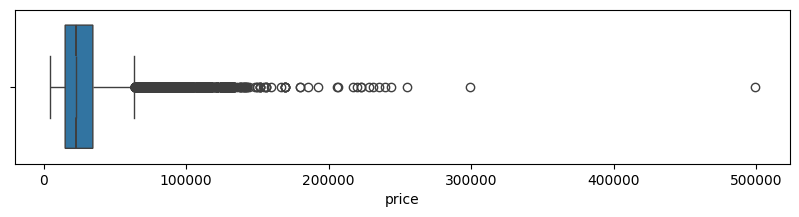

In [ ]:
# аналогично взглянем на столбец "price"
plt.figure(figsize=(10, 2))
sns.boxplot(x=auto.price, notch=True)
plt.show()

In [ ]:
# дополнительно посмотрим на характер распределения данного параметра
auto.price.describe()

count     32854.000000
mean      29745.856890
std       22364.077937
min        4571.358913
25%       15141.580725
50%       22819.022589
75%       34568.063195
max      498787.514716
Name: price, dtype: float64

*В поле "price" содержится информация о цене единичного экземпляра авто и как мы видим, минимальная цена на авто равна 4571 долларов, а большинство цен находится в диапазоне до 70000 долларов. Далее от 70000 до 300000 долларов следует массив из аномальных цен и один факт упоминания самой аномально высокой цены 500000 долларов. Посмотрим на бренд, модель авто, год выпуска с самой низкой ценой, а так же на бренд, модель, год выпуска и по какой цене были проданы авто с ценой выше 200000 долларов*

In [ ]:
# сперва взглянем на авто по цене дешевле 5000
auto.query('price < 5000')[['brand_auto', 'model_auto', 'year_prod', 'price']]

,brand_auto,model_auto,year_prod,price
32332,Jac,X200,2016-01-01,4571.358913


In [ ]:
# выполним определенный срез данных
auto.query('price > 200000')[['brand_auto', 'model_auto', 'year_prod', 'price']]

,brand_auto,model_auto,year_prod,price
7145,Hyundai Truck & Bus,Universe,2017-01-01,243827.222122
7146,Hyundai Truck & Bus,Universe,2017-01-01,222639.770983
7147,Hyundai Truck & Bus,Universe,2017-01-01,222639.770983
7148,Hyundai Truck & Bus,Universe,2017-01-01,239203.974035
7149,Hyundai Truck & Bus,Universe,2017-01-01,228003.973125
7150,Hyundai Truck & Bus,Universe,2017-01-01,219843.456215
15776,Mercedes-Benz Trucks,Tourismo,2018-01-01,254958.000000
17146,Porsche,911 Carrera S,2018-01-01,205962.374664
17192,Porsche,Panamera,2017-01-01,206882.074184
17194,Porsche,Panamera,2017-01-01,235378.952664


*Как мы можем видеть, авто, что было продано по цене 4571 долларов представленно брэндом Jac модели X200 2016 года выпуска (грузовик для малого бизнеса), прайс которого соответствует действительности. Продажи по цене выше 200000 долларов представлены новыми (2017, 2018) или элитными брэндами или качественными грузовиками в основном в единичном количестве. Стоит обратить внимание на авто брэнда "Урал", модели 4320 (цена, за единицу которого 298875 долларов, как указано) и дополнительно, более внимательно изучить данные о нем*

In [ ]:
# выполним опредеденный срез в данных
auto[(auto['brand_auto'] == 'Урал') & (auto['model_auto'] == '4320')]

,year_sell,month_sell,company,brand_auto,model_auto,year_prod,country_prod,petrol,engine,gearbox,type_drive,region,count_auto,price,final_price,state,segment,class_2013,order_date
32035,2019,1,Семаз,Урал,4320,NaT,KAZ,unknown,0.0,at,2wd,Астана,1,69230.025894,6.923003e+04,г.Астана,Коммерческие автомобили,Малотоннажные грузовики,2019-01-01
32036,2019,2,Семаз,Урал,4320,2014-01-01,KAZ,unknown,0.0,at,2wd,Актобе,1,49697.268203,4.969727e+04,Актюбинская область,Коммерческие автомобили,Малотоннажные грузовики,2019-02-01
32037,2019,3,Семаз,Урал,4320,2017-01-01,KAZ,unknown,0.0,at,2wd,Семей,1,40929.702604,4.092970e+04,Восточно-Казахстанская область,Коммерческие автомобили,Малотоннажные грузовики,2019-03-01
32038,2019,5,Семаз,Урал,4320,2016-01-01,KAZ,unknown,0.0,at,2wd,Астана,1,38094.657605,3.809466e+04,г.Астана,Коммерческие автомобили,Малотоннажные грузовики,2019-05-01
32039,2019,6,Семаз,Урал,4320,2018-01-01,KAZ,unknown,0.0,at,2wd,Алматы,14,46185.432040,6.465960e+05,г.Алматы,Коммерческие автомобили,Малотоннажные грузовики,2019-06-01
32040,2019,6,Семаз,Урал,4320,2018-01-01,KAZ,unknown,0.0,at,2wd,Алматы,6,49809.569150,2.988574e+05,г.Алматы,Коммерческие автомобили,Малотоннажные грузовики,2019-06-01
32041,2019,6,Семаз,Урал,4320,2018-01-01,KAZ,unknown,0.0,at,2wd,Алматы,1,298875.267793,2.988753e+05,г.Алматы,Коммерческие автомобили,Малотоннажные грузовики,2019-06-01
32042,2019,6,Семаз,Урал,4320,2018-01-01,KAZ,unknown,0.0,at,2wd,Астана,3,38681.266365,1.160438e+05,г.Астана,Коммерческие автомобили,Малотоннажные грузовики,2019-06-01
32043,2019,6,Семаз,Урал,4320,2018-01-01,KAZ,unknown,0.0,at,2wd,Астана,1,38681.266365,3.868127e+04,г.Астана,Коммерческие автомобили,Малотоннажные грузовики,2019-06-01
32044,2019,7,Семаз,Урал,4320,2018-01-01,KAZ,unknown,0.0,at,2wd,Алматы,1,95184.178716,9.518418e+04,г.Алматы,Коммерческие автомобили,Малотоннажные грузовики,2019-07-01


*По полученным данным можно сказать, что цена за единичный экземпляр авто модели и бренда "Урал 4320" в основном находится в диапазоне 38000 - 115000 долларов, что в принципе допустимо, но обнаружен единственный факт наличия цены около 300000 долларов, что подозрительно (такая же цена обозначена в поле "final_price"). Вероятно в поле "price" была ошибочно внесена информация о финальной цене за 6 единиц авто, так как в соседней ячейке отражена аналогичная сумма как раз за 6 единиц авто модели "Урал 4320", по цене 49809 долларов за каждую. Приведем в порядок обнаруженные несоответствия*

In [ ]:
# внесем изменения в строку таблицы под определенным индексом
auto.loc[32041, 'count_auto'] = 6
auto.loc[32041, 'price'] = 49809.569150

In [ ]:
# и повторно взглянем на результат
auto.query('price > 200000')[['brand_auto', 'model_auto', 'year_prod', 'price']]

,brand_auto,model_auto,year_prod,price
7145,Hyundai Truck & Bus,Universe,2017-01-01,243827.222122
7146,Hyundai Truck & Bus,Universe,2017-01-01,222639.770983
7147,Hyundai Truck & Bus,Universe,2017-01-01,222639.770983
7148,Hyundai Truck & Bus,Universe,2017-01-01,239203.974035
7149,Hyundai Truck & Bus,Universe,2017-01-01,228003.973125
7150,Hyundai Truck & Bus,Universe,2017-01-01,219843.456215
15776,Mercedes-Benz Trucks,Tourismo,2018-01-01,254958.000000
17146,Porsche,911 Carrera S,2018-01-01,205962.374664
17192,Porsche,Panamera,2017-01-01,206882.074184
17194,Porsche,Panamera,2017-01-01,235378.952664


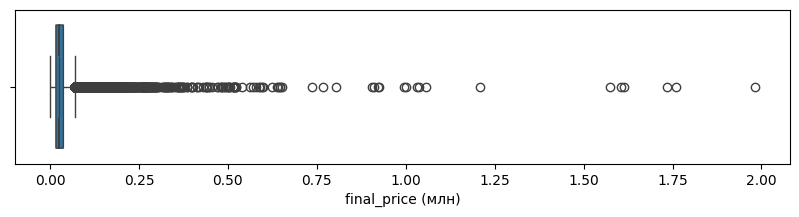

In [ ]:
# теперь взглянем на столбец "final_price"
plt.figure(figsize=(10, 2))
sns.boxplot(x=auto.final_price/1000000, notch=True)
plt.xlabel('final_price (млн)')
plt.show()

In [ ]:
# более тонко посмотрим на характер распределения данного параметра
auto.final_price.describe(percentiles=[.9995])

count     3.285400e+04
mean      3.529557e+04
std       4.607861e+04
min       0.000000e+00
50%       2.553389e+04
99.95%    7.883715e+05
max       1.980922e+06
Name: final_price, dtype: float64

*В поле "final_price" содержится информация о фактической сумме продажи авто, с учетом их количества и остальных нюансов. Как мы видим в основном окончательная цена находится в диапазоне около 10000 долларов и меньше. Дополнительно посмотрим на брэнд, модель авто, цену и то в каком количестве были проданы авто, окончательная цена которых превышает 800000 долларов (таких продаж обнаружено не более 0.05%). А также взглянем на информацию об авто, где данные в поле "final_price" равны нулю и при наличии информации о количестве проданных авто и изначальном прайсе попробовать их восстановить*

In [ ]:
# так же выполним срез данных
auto.query('final_price > 800000')[['brand_auto', 'model_auto', 'count_auto', 'year_prod', 'final_price']]

,brand_auto,model_auto,count_auto,year_prod,final_price
959,Daewoo,BS 106 A,9,2018-01-01,9.229493e+05
960,Daewoo,BS 106 A,10,2018-01-01,1.000838e+06
962,Daewoo,BS 106 A,20,2018-01-01,1.980922e+06
1157,Foton,BJ3253DMPKB-AD,18,NaT,9.953497e+05
7149,Hyundai Truck & Bus,Universe,4,2017-01-01,9.120159e+05
11372,Kia,Optima,40,2018-01-01,9.040000e+05
13420,Lada,Vesta,91,2018-01-01,1.055600e+06
14078,Land Rover,Range Rover,13,2018-01-01,1.733955e+06
20234,Scania,R-Series,14,2018-01-01,1.761147e+06
20240,Scania,R-Series,13,2018-01-01,1.604547e+06


*Как мы можем видеть, все продажи по цене выше 800000 долларов в основном представлены качественными грузовиками (за исключением Kia Optima, Lada Vesta и Land Rover) в количестве от 4 и до нескольких десятков*

In [ ]:
# теперь посмотрим на авто и то в каком они количестве, финальная цена за которые не указана
auto.query('final_price == 0')[['brand_auto', 'model_auto', 'count_auto', 'price']]

,brand_auto,model_auto,count_auto,price
11525,Kia,Rio,<NA>,13500.0
11665,Kia,Sorento,<NA>,30400.0
11927,Kia,Sportage,<NA>,20700.0
13062,Lada,Largus,<NA>,12000.0
30606,UAZ,3741,<NA>,16200.0


In [ ]:
# повторно посмотрим на количество пропусков в поле "count_auto"
auto.count_auto.isna().sum()

5

*Как мы видим, информация о финальной цене отсутствует ровно в тех строках, где имеются пропуски в поле с количеством проданных авто. Оставим данные без изменений*

In [ ]:
# более детально взглянем на поле "segment"
auto.segment.unique()

array(['Легковые автомобили ', 'Внедорожники ',
       'Коммерческие автомобили ', 'Минивэны', 'Пикапы '], dtype=object)

*Данные выглядят вполне корректными, разве что можно привести к нижнему регистру и избавиться от лишних пробелов*

In [ ]:
# приведем к нижнему регистру и исключим пробелы
auto.segment = auto.segment.str.lower().str.strip()
auto.segment.unique() # и повторно взглянем на результат

array(['легковые автомобили', 'внедорожники', 'коммерческие автомобили',
       'минивэны', 'пикапы'], dtype=object)

In [ ]:
# так же посмотрим на данные в поле "class_2013"
auto.class_2013.unique()

array(['C класс ', 'D класс ', 'Спортивные автомобили ', 'E класс ',
       'F класс ', 'Среднеразмерные SUV ', 'Стандартные SUV ', 'B класс ',
       'Компактные SUV ', 'Субкомпактные SUV ', 'Большие автобусы ',
       'Микроавтобусы ', 'Малотоннажные грузовики ',
       'Крупнотоннажные грузовики ', 'Развозные автомобили ',
       'Среднетоннажные грузовики ', 'Полноразмерный Минивэн ',
       'Средние автобусы ', 'Полноразмерные SUV ', 'Pick-ups', 'A класс ',
       'Компактвэн'], dtype=object)

*В поле "class_2013" данные также выглядят вполне корректными. Аналогично приведем их к единому регистру и удалим все лишние пробелы*

In [ ]:
# приведем к нижнему регистру и исключим пробелы
auto.class_2013 = auto.class_2013.str.lower().str.strip()
auto.class_2013.unique() # и повторно взглянем на результат

array(['c класс', 'd класс', 'спортивные автомобили', 'e класс',
       'f класс', 'среднеразмерные suv', 'стандартные suv', 'b класс',
       'компактные suv', 'субкомпактные suv', 'большие автобусы',
       'микроавтобусы', 'малотоннажные грузовики',
       'крупнотоннажные грузовики', 'развозные автомобили',
       'среднетоннажные грузовики', 'полноразмерный минивэн',
       'средние автобусы', 'полноразмерные suv', 'pick-ups', 'a класс',
       'компактвэн'], dtype=object)

##Результаты предобработки данных

* на этапе предобработки данных было выполнено следующее:
  * были удалены поля, содержащие не столь актуальную или повторно дублирующие информацию ("Unnamed: 0", "Модификация", "Сегмент", "Наименование дилерского центра", "Тип клиента", "Форма расчета", "Область", "Сегментация Eng", "Локализация производства")
  * названия полей приведены к единому стилю (нижний регистр и "змеиный" стиль)
  * далее на основе столбцов "year_sell", "month_sell" (заменили наименование месца на его порядковый номер) создали дополнительный "order_date", содержащий дату (год и месяц) продажи, а в поле "year_prod" после преобразования некоторых некорректных значений заменили тип данных на datetime
  * в поле "count_auto" (количество проданных авто) тип данных заменили на int, как наиболее предпочтительный. А затем проверили характер распределения данных. В основном авто были проданы в единичном количестве, но так же не мало продаж в количестве до 40. Было обнаружено 3 факта продажи в количестве около 50, 60 и 90 авто, которые как оказалось представлены брэндом "Lada", а продажи стоят только за одной компанией "Бипэк авто", которая фактически является сетевым предприятием (практически на территории 20 городов Казахстана), осуществляющим продажу и обслуживание автомобилей. Вполне вероятно, что подобные массовые продажи были произведены какой-либо службе такси, с целью пополнения авто-парка
  * далее в поле "company" названия компаний привели к единому регистру, удалив лишние пробелы и заменили те, что дублировали наименования компаний посредством киррилического алфавита
  * в поле "country_prod" (страна производитель) названия стран были закодированы в alpha3
  * затем в поле "petrol" (тип топлива) все данные были приведены к общему стилю (регистр, пробелы), а пропуска заполнены модой по модели авто. В следствии чего было получено 6 категорий: бензин, дизель, гибрид, электро, газ и unknown. А доля отсутствующих данных снизилась с 2.7% до 0.46%
  * в столбце "engine" (объем двигателя) заменили дробный разделитель "," на ".", а отсутстующие и некорректные данные аналогично заполнили модой по модели авто. Далее более внимательно взяглянули на те модели, объем двигателя которых превышает 10л (они представлены крупными грузовиками и тягачами, что вполне логично). В следствии обработки доля отсутствующих данных снизилась с 5.7% до 3.6%
  * далее в столбце "gearbox" (тип коробки передач) данные привели к единому стилю (регистр, пробелы), а некорректные значения заменили. В результате получили две категории: at (автоматическая) и mt (механическая)
  * в поле "type_drive" (тип привода) аналогично данные были приведены к единообразию (регистр, пробелы), а некорректные значения были заменены. По итогу данные распределены между следующими категориями: 2wd (задний или передний привод), fwd (передний привод), 4wd (полный привод), rwd (задний привод)
  * в столбце "region" (регион Казахстана, где была произведена продажа) так же данные были приведены к единому стилю (регистр, пробелы)
  * в поле "price" (цена, USD) по итогам проверки данных на наличие выбросов можно определить, что минимальная цена проданного авто равна 4571 доллару и представлена брэндом Jac модели X200 2016 года выпуска (грузовик для малого бизнеса), прайс которого соответствует действительности. Большинство продаж было произведено по цене до 70000 долларов. Далее от 70000 до 300000 долларов следует массив из аномальных цен и один факт упоминания самой аномально высокой цены 500000 долларов. Как мы можем видеть, продажи по цене выше 200000 долларов представлены или элитными брэндами или качественными грузовиками в основном в единичном количестве. Дополнительно и более внимательно изучили информацию об авто брэнда "Урал", модели 4320, цена за единицу которого как указано в данных 298875$, что выглядит подозрительно (как оказалось такая же цена обозначена в поле "final_price"). После определенного среза в данных можно сказать, что цена за единичный экземпляр авто модели и бренда "Урал 4320" в основном находится в диапазоне 38000 - 115000 долларов, что в принципе допустимо. Вероятно в поле "price" была ошибочно внесена информация о финальной цене за 6 единиц авто, так как в соседней ячейке отражена аналогичная сумма как раз за 6 единиц авто модели "Урал 4320", по цене 49809 долларов за каждую. В соответствии с полученными выводами некорректные данные были заменены
  * в поле "last_price" (последняя цена, USD) по итогам проверки данных на наличие выбросов  можно определить, что в основном окончательная цена находится в диапазоне около 10000 долларов и меньше. Как мы можем видеть, также присутствует множество аномально высоких цен. Все продажи по цене выше 800000 долларов в основном представлены качественными грузовиками (за исключением Kia Optima, Lada Vesta и Land Rover) в количестве от 4 и до нескольких десятков, что соответствует действительности. Так же обнаружено несколько нулевых значений (помимо отсутствия информации о финальной цене данные строки также имеют пропуски в поле "count_auto"). Решено оставить данные без изменений
  * далее преобразовали данные в столбцах "segment" и "class_2013" , приведя их к единому стилю (регистр, пробелы)

#Исследовательский анализ данных

##Оценка основных параметров

In [ ]:
# применим возможности библиотеки profiling
ProfileReport(auto, title='Report') # и сформируем отчет по датасету auto

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

##Исследовательский анализ. Общие выводы

* датасет auto содержит 18 столбцов и 32854 строки. Следовательно всего за 2019 год в Казахстане было произведено (внесено в данный датасет) 32854 продажи на общую сумму порядка 1159600568 долларов. Проанализируем наиболее интересные параметры датасета:
  * в поле "company" (наименования компании, продающих авто) больше всех продаж выполено компанией "Toyota motor kazakhstan" (10442 продажи), затем по убыванию следуют "Astana motors" (5746 продаж), "Бипэк авто" (3595 продаж), "Вираж" (3358 продаж), Узавто-казахстан (1727 продаж). Всего мы располагаем информацией о 33 уникальных компаниях, занимающихся продажей авто в Казахстане
  * наиболее популярным брэндом авто в Казахстане за 2019 год является Toyota (9374 продажи), далее по убыванию популярности следует Hyundai (5703 продажи), Lada (2116 продаж), GAZ (2111 продажа), Ravon (1727 продаж)
  * а наиболее популярной моделью стала модель "Camry" (3440 продажи), затем следует "Tucson" (1890 продаж), "LC Prado" (1489 продаж), "RAV4" (1348 продаж), Accent (1332 продажи). Как мы видим, самые популярные модели относятся к наиболее популярным брэндам (Toyota, Hyundai)
  * чаще всего покупали новые авто 2018 года выпуска (23466 продаж), реже покупали авто 2017 года выпуска (8957 продаж), еще реже 2016 (233 продажи) и так в порядке убывания до 2012 года выпуска (таких всего 2 продажи)
  * чаще всего страной производителем является Россия (12175), Казахстан (11526), Япония (4980), Турция (1214), Узбекистан (1177)
  * в основном проданные автомобили в качестве топлива используют бензин (30902) и лишь небольшая часть из них (1681) дизель
  * наиболее распространенный объем двигателя 1.6 литра (легковой авто, те самые модели, что являются наиболее популярными часто имеют двигатель данного объема - 6792 продаж), затем по убыванию популярности следует объем 2.0 литра (6399 продаж данных авто), 2.7 литра (4651 продажа) и 2.5 литра (4098 продаж)
  * в основном проданные авто имеют автоматическую коробку передач (23030 продаж), авто с механической коробкой передач (9824 продажи)
  * в основном (26141 продажа) проданные авто имеют двухколесный привод (точно не было указано), значительно реже указано что привод передний (4106 продаж), либо полный (2408 продаж)
  * в основном магазины, продавшие авто находится на территории региона Алматы (9264), Астана (7050), Атырау (2078), Костанай (2030) и Шымкент (2025)
  * в 30389 случаях авто были проданы в единичном экземпляре, в 953 случаях в количестве 2 экземпляров, в количестве 3 экземпляров авто были проданы в 425 случаях, в 237 случаях авто были проданы в количестве 4 экземпляров. Далее по убыванию, чем больше количество авто, тем реже были такие продажи и так вплоть до максимального количество проданных авто (91 единица)
  * подавляющее большинство проданных авто имели цены до 50000 долларов, самая низкая зафиксированная цена авто - 4571 долларов, а самая максимальная - 498787 долларов. Средняя цена проданных авто - 29738 долларов, а наиболее распространенная - 13800 долларов
  * чаще всего окончательная цена с учетом всех комплектаций и количества продаваемых авто была в диапазоне 15000 - 50000 долларов. Самая низкая зафиксированная цена продажи равна 0 (данные о количестве проданных авто в поле "count_auto" занесены не были), а самая высокая зафиксированная цена продажи - 1980922.2 долларов (представлена 20 грузовиками Daewoo). Средняя цена финальной продажи - 35295 долларов, а наиболее распространенная 13800 долларов
  * чаще всего покупатели приобретали внедорожники (14267 продаж), немного реже легковые авто (13342 продажи), далее коммерческие авто (4251 продажа), пикапы (933 продажи) и минивэны (61 продажа)
  * среди проданных авто наиболее распростарнены авто класса b (6108 продаж), далее по убыванию компактный suv (4841 продажа), e класс (3731 продажа), c класс (3171 продажа) и среднеразмерный suv (2963 продажи)
  * меньше всего продаж было в январе 2019 (около 2500 продаж), затем вплоть до мая происходит рост продаж до порядка немного выше 4000 продаж, далее в июле небольшая просадка ниже 4000 продаж, а после восстановление на прежние уровни. Как мы видим в летний период потребительский спрос находится на своих пиковых отметках, что соответствует действительности
  * из интересных взаимосвязей можно отметить положительную корреляцию поля "engine" (объем двигателя) с другими техническими характеристиками авто (тип коробки передач, поле "gearbox" - 0.691, тип топлива, поле "petrol" - 0.599), а так же с его классом ("class_2013" - 0.481) и стоимостью ("price" - 0.594)

#Аналитическая часть

##Анализ рынка автомобилей

*Разделим общий рынок авто Казахстана на коммерческие авто (всего из 32854 продаж для коммерческих целей было продано 4251 авто) и не коммерческие (все остальные). Для этих целей создадим дополнительный столбец "commercial"*

In [ ]:
# выведем новую категорию для авто "коммерческий/не"
def com(row):
  if str(row) == "коммерческие автомобили":
    return "коммерция"
  else:
    return "не коммерция"

In [ ]:
# создадим новое поле с наименованием "commercial"
auto['commercial'] = auto.segment.apply(com)

In [ ]:
# взглянем на результат
auto.sample()

,year_sell,month_sell,company,brand_auto,model_auto,year_prod,country_prod,petrol,engine,gearbox,type_drive,region,count_auto,price,final_price,state,segment,class_2013,order_date,commercial
29203,2019,3,Toyota motor kazakhstan,Toyota,RAV4,2017-01-01,JPN,бензин,2.0,at,2wd,Астана,1,29622.938716,29622.938716,г.Астана,внедорожники,среднеразмерные suv,2019-03-01,не коммерция


###Основные параметры рынка авто (емкость рынка, лидеры рынка, динамика рынка)

####Емкость рынка (в количественном и денежном отношении)

In [ ]:
# разобьем данные по признаку "commercial"
auto_com_count = auto.groupby('commercial')['count_auto'].sum().reset_index()
auto_com_count

,commercial,count_auto
0,коммерция,4895
1,не коммерция,39067


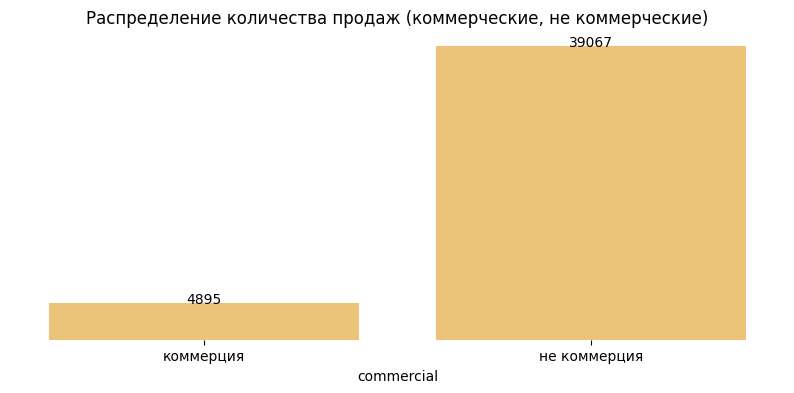

In [ ]:
# визуализируем количественную емкость рынка
plt.figure(figsize=(10, 4))

a_cu = auto_com_count.count_auto.tolist() # для удобства при визуализации сохраним в переменную количество продаж
sns.barplot(auto_com_count, x='commercial', y='count_auto', alpha=0.6, color='orange') # построим столбчатую диаграмму

for i in range(len(a_cu)):
        plt.text(i, a_cu[i], int(a_cu[i]), horizontalalignment='center') # добавим подписи над барами

ax = plt.gca ()
ax.get_yaxis().set_visible(False) # исключим ось y

for spine in ['left', 'right', 'bottom', 'top']:
    ax.spines[spine].set_visible(False) # уберем рамки

plt.title('Распределение количества продаж (коммерческие, не коммерческие)')
plt.show()

In [ ]:
# повторно разобьем данные по признаку "commercial"
auto_com_mon = auto.groupby('commercial')['final_price'].sum().reset_index() # и оценим денежный объем
auto_com_mon.final_price = auto_com_mon.final_price/1000000 # определим суммы в миллионах долларов
auto_com_mon

,commercial,final_price
0,коммерция,169.260125
1,не коммерция,990.340443


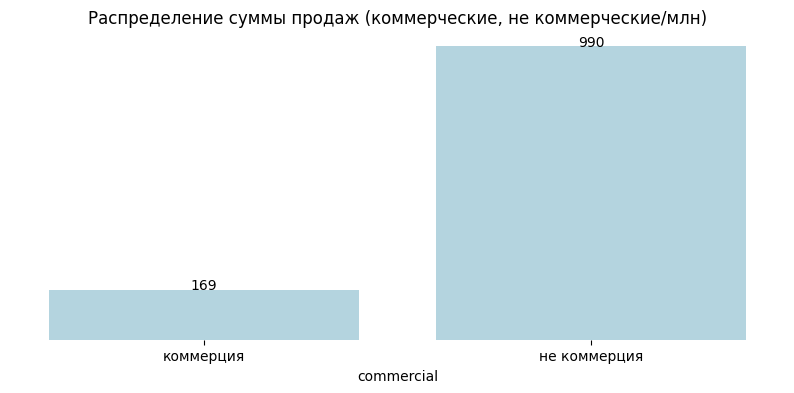

In [ ]:
# теперь визуализируем денежную емкость рынка (млн. долларов)
plt.figure(figsize=(10, 4))

a_cm = auto_com_mon.final_price.tolist() # для удобства при визуализации сохраним в переменную суммы продаж
sns.barplot(auto_com_mon, x='commercial', y='final_price', color='lightblue') # построим столбчатую диаграмму

for i in range(len(a_cm)):
        plt.text(i, a_cm[i], int(a_cm[i]), horizontalalignment='center') # добавим подписи над барами

ax = plt.gca ()
ax.get_yaxis().set_visible(False) # исключим ось y

for spine in ['left', 'right', 'bottom', 'top']:
    ax.spines[spine].set_visible(False) # уберем рамки

plt.title('Распределение суммы продаж (коммерческие, не коммерческие/млн)')
plt.show()

####Брэнды-лидеры рынка (коммерческие/не коммерческие)

In [ ]:
# определим топ наиболее часто продаваемых брэндов для коммерческих целей в Казахстане
auto_com_top = auto.query('commercial == "коммерция"').groupby('brand_auto')['count_auto'].sum().sort_values(ascending=False).reset_index()
auto_com_top.columns = ['brand_auto', 'total_count']
auto_com_top.head(5)

,brand_auto,total_count
0,GAZ,2111
1,KAMAZ,888
2,UAZ,708
3,Hyundai Truck & Bus,177
4,Урал,118


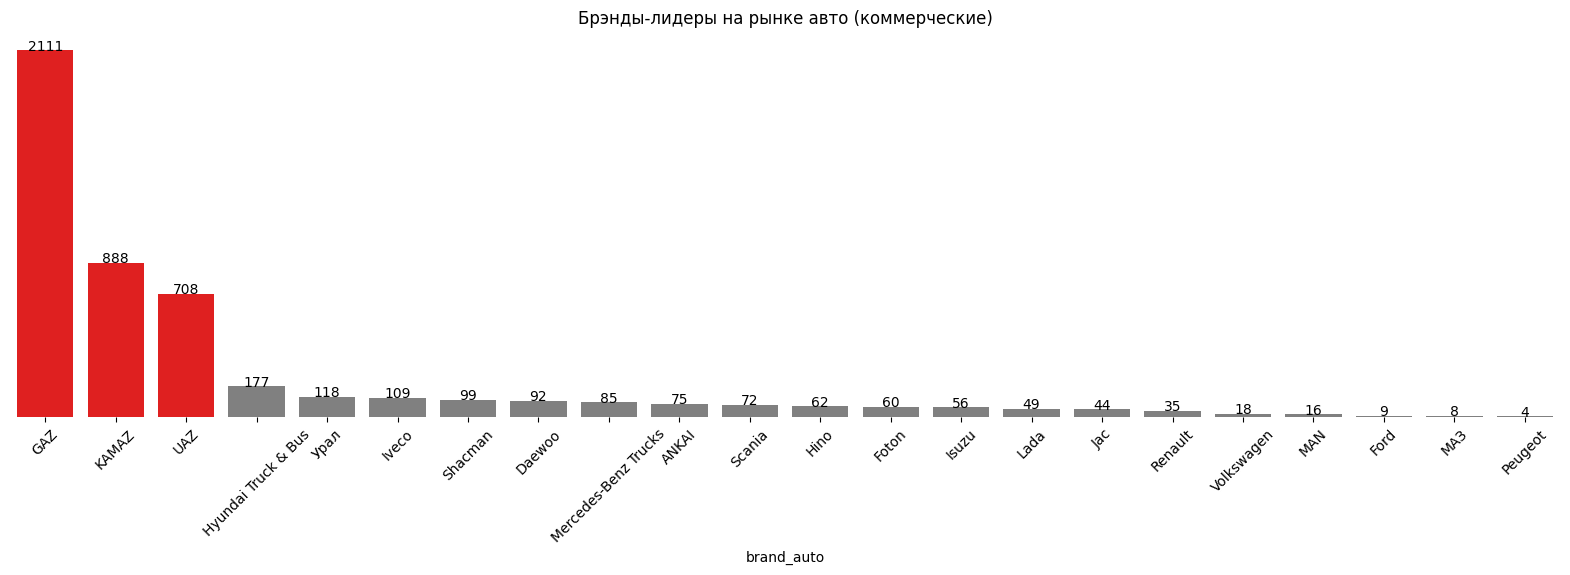

In [ ]:
# визуализируем распределение продаж по брэндам для коммерческих целей
plt.figure(figsize=(20, 5))

a_cm_tp = auto_com_top.total_count.tolist()
colors = ['gray'] * 22
colors[0], colors[1], colors[2] = 'red', 'red', 'red' # зададим цветовую гамму графика, выделим топ-3
sns.barplot(auto_com_top, x='brand_auto', y='total_count', palette=colors) # построим столбчатую диаграмму

for i in range(len(a_cm_tp)):
        plt.text(i, a_cm_tp[i], int(a_cm_tp[i]), horizontalalignment='center') # добавим подписи над барами

ax = plt.gca ()
ax.get_yaxis().set_visible(False) # исключим ось y

for spine in ['left', 'right', 'bottom', 'top']:
    ax.spines[spine].set_visible(False) # уберем рамки

plt.title('Брэнды-лидеры на рынке авто (коммерческие)')
plt.xticks(rotation=45)
plt.show()

In [ ]:
# определим топ наиболее часто продаваемых брэндов не для коммерческих целей в Казахстане
auto_nocom_top = auto.query('commercial == "не коммерция"').groupby('brand_auto')['count_auto'].sum().sort_values(ascending=False).reset_index()
auto_nocom_top.columns = ['brand_auto', 'total_count']
auto_nocom_top.head(5)

,brand_auto,total_count
0,Lada,9618
1,Toyota,9374
2,Hyundai,5703
3,Kia,1815
4,Ravon,1727


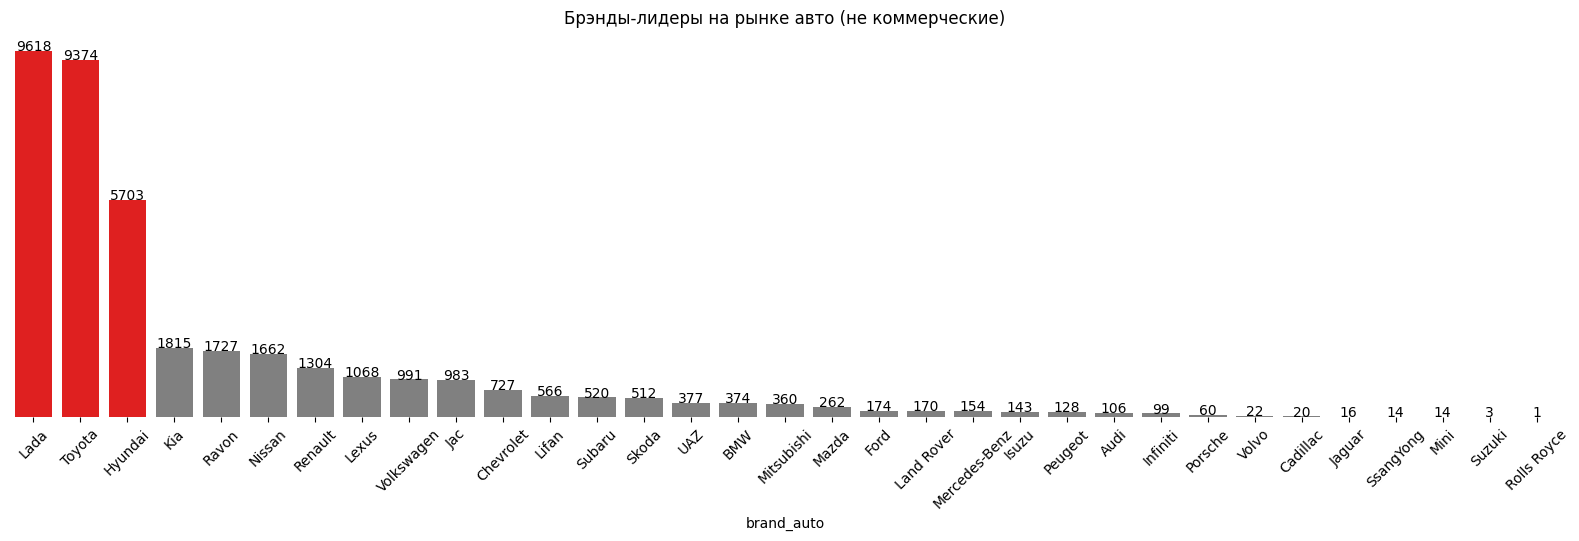

In [ ]:
# аналогично визуализируем распределение продаж по брэндам для не коммерческих целей
plt.figure(figsize=(20, 5))

a_ncm_tp = auto_nocom_top.total_count.tolist()
colors = ['gray'] *33
colors[0], colors[1], colors[2] = 'red', 'red', 'red' # зададим цветовую гамму графика, выделим топ-3
sns.barplot(auto_nocom_top, x='brand_auto', y='total_count', palette=colors) # построим столбчатую диаграмму

for i in range(len(a_ncm_tp)):
        plt.text(i, a_ncm_tp[i], int(a_ncm_tp[i]), horizontalalignment='center') # добавим подписи над барами

ax = plt.gca ()
ax.get_yaxis().set_visible(False) # исключим ось y

for spine in ['left', 'right', 'bottom', 'top']:
    ax.spines[spine].set_visible(False) # уберем рамки

plt.title('Брэнды-лидеры на рынке авто (не коммерческие)')
plt.xticks(rotation=45)
plt.show()

####Динамика рынка (в количественном и денежном отношении, коммерческие/не коммерческие)

In [ ]:
# взглянем, как изменялось количество продаж в течении всего времени
count_sell = auto.groupby('order_date')['count_auto'].sum().to_frame().reset_index()

In [ ]:
# для удобства создадим переменные со значениями для графика
x = count_sell.order_date.tolist()
y = count_sell.count_auto.tolist()

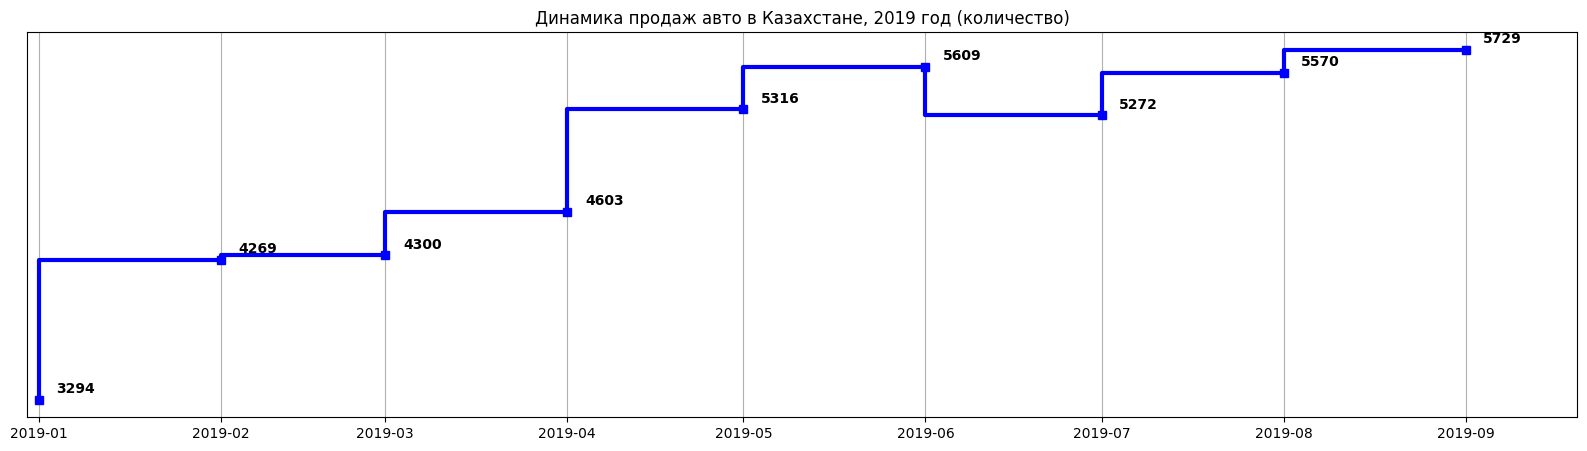

In [ ]:
# посмотрим на то, как изменялось количество продаж в течении 2019 года
plt.figure(figsize=(20, 5))
plt.title('Динамика продаж авто в Казахстане, 2019 год (количество)')

plt.step(x, y, linewidth=3, marker='s', color='blue')
plt.xlim(pd.to_datetime('2018-12-30', format='%Y-%m-%d'), pd.to_datetime('2019-09-20', format='%Y-%m-%d'))


for xx, yy, tex in zip(x, y, y):
    t = plt.text(xx+pd.Timedelta(3, 'd'), yy+25, int(tex),
                 horizontalalignment='left',
                 rotation='horizontal',
                 verticalalignment='bottom',
                 fontdict={'color':'black', 'weight':'bold'})

ax = plt.gca()
ax.get_yaxis().set_visible(False)
plt.grid()

In [ ]:
# взглянем, как изменялось количество продаж в течении 2019 года (коммерческие/не коммерческие)
count_sell_comm = auto.query('commercial == "коммерция"').groupby('order_date')['count_auto'].sum().to_frame().reset_index()
count_sell_nocomm = auto.query('commercial == "не коммерция"').groupby('order_date')['count_auto'].sum().to_frame().reset_index()

In [ ]:
# для удобства создадим переменные со значениями для графика
x_comm = count_sell_comm.order_date.tolist()
y_comm = count_sell_comm.count_auto.tolist()

x_nocomm = count_sell_nocomm.order_date.tolist()
y_nocomm = count_sell_nocomm.count_auto.tolist()

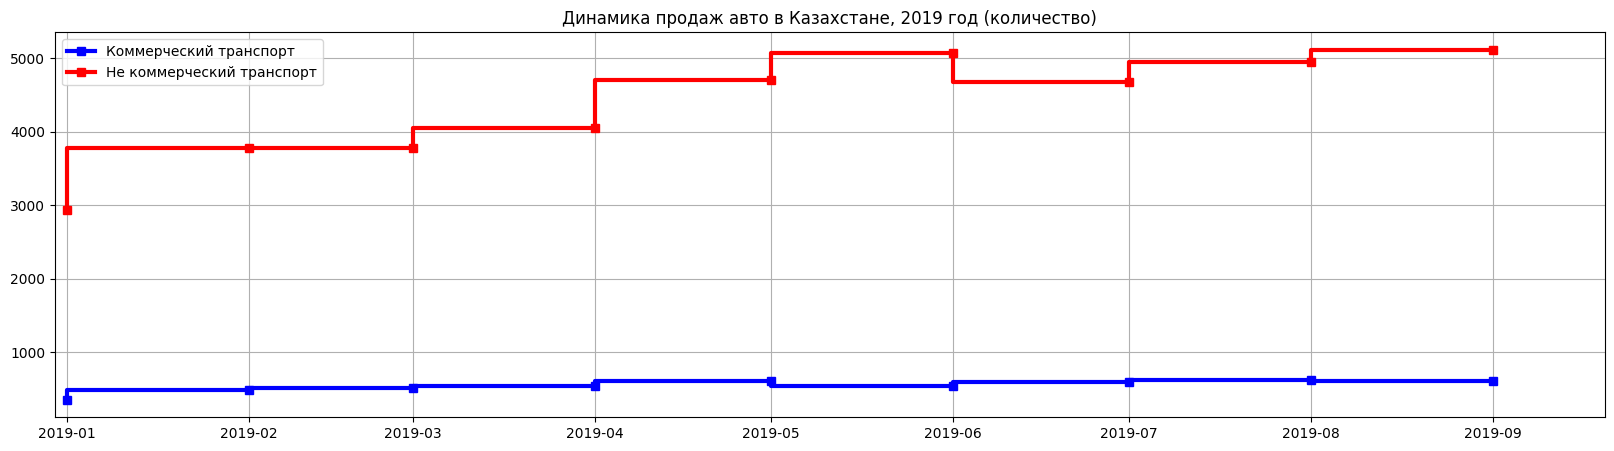

In [ ]:
# посмотрим на то, как изменялось количество продаж в течении 2019 года (коммерческие/не коммерческие)
plt.figure(figsize=(20, 5))

plt.title('Динамика продаж авто в Казахстане, 2019 год (количество)')
plt.step(x_comm, y_comm, linewidth=3, marker='s', color='blue', label='Коммерческий транспорт')
plt.xlim(pd.to_datetime('2018-12-30', format='%Y-%m-%d'), pd.to_datetime('2019-09-20', format='%Y-%m-%d'))

plt.title('Динамика продаж авто в Казахстане, 2019 год (количество)')
plt.step(x_nocomm, y_nocomm, linewidth=3, marker='s', color='red', label='Не коммерческий транспорт')
plt.xlim(pd.to_datetime('2018-12-30', format='%Y-%m-%d'), pd.to_datetime('2019-09-20', format='%Y-%m-%d'))

plt.legend()
plt.grid()
plt.show()

*Посредством ступенчатого графика визуализируем динамику рынка в денежном отношении*

In [ ]:
# взглянем, как изменялись суммы продаж в течении всего времени
total_sell = auto.groupby('order_date')['final_price'].sum().to_frame().reset_index()

In [ ]:
# для удобства создадим переменные со значениями для графика
x1 = total_sell.order_date.tolist()
y1 = total_sell.final_price.tolist()
y1 = [y2 / 1000000 for y2 in y1]

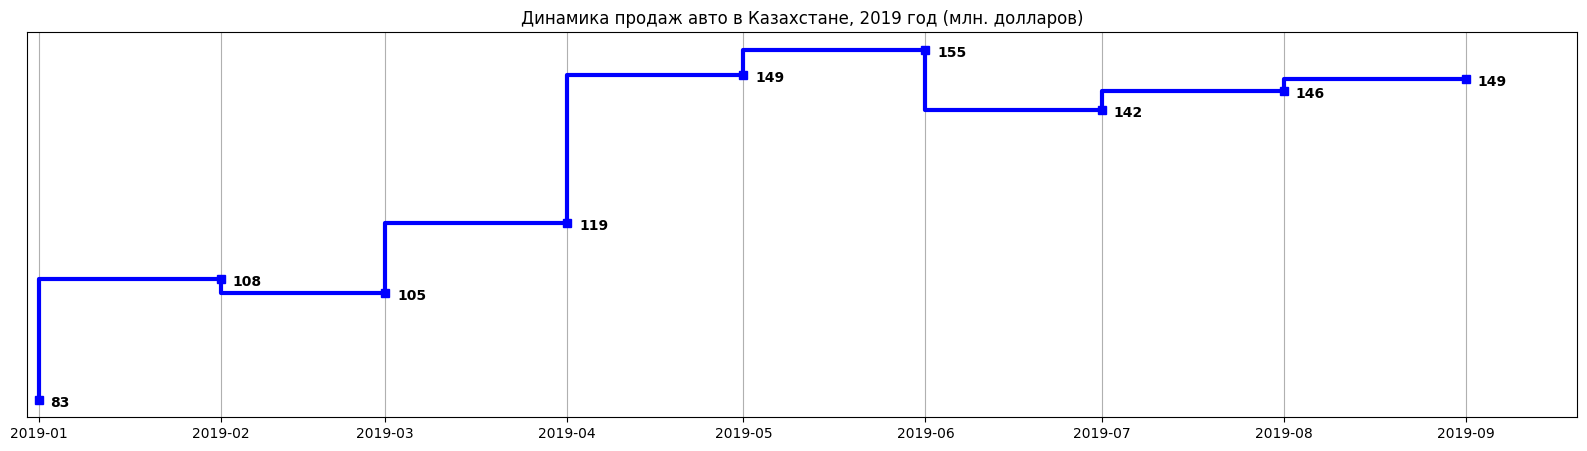

In [ ]:
# посмотрим на то, как изменялись суммы продаж в течении 2019 года
plt.figure(figsize=(20, 5))
plt.title('Динамика продаж авто в Казахстане, 2019 год (млн. долларов)')

plt.step(x1, y1, linewidth=3, marker='s', color='blue')
plt.xlim(pd.to_datetime('2018-12-30', format='%Y-%m-%d'), pd.to_datetime('2019-09-20', format='%Y-%m-%d'))


for xx, yy, tex in zip(x1, y1, y1):
    t = plt.text(xx+pd.Timedelta(2, 'd'), yy-2, int(tex),
                 horizontalalignment='left',
                 rotation='horizontal',
                 verticalalignment='bottom',
                 fontdict={'color':'black', 'weight':'bold'})

ax = plt.gca()
ax.get_yaxis().set_visible(False)
plt.grid()

In [ ]:
# взглянем, как изменялись суммы продаж в течении 2019 года (коммерческие/не коммерческие)
total_sell_comm = auto.query('commercial == "коммерция"').groupby('order_date')['final_price'].sum().to_frame().reset_index()
total_sell_nocomm = auto.query('commercial == "не коммерция"').groupby('order_date')['final_price'].sum().to_frame().reset_index()

In [ ]:
# для удобства создадим переменные со значениями для графика
x_tot_comm = total_sell_comm.order_date.tolist()
y_tot_comm = total_sell_comm.final_price.tolist()

x_tot_nocomm = total_sell_nocomm.order_date.tolist()
y_tot_nocomm = total_sell_nocomm.final_price.tolist()

y_tot_comm = [y1 / 1000000 for y1 in y_tot_comm]
y_tot_nocomm = [y1 / 1000000 for y1 in y_tot_nocomm]

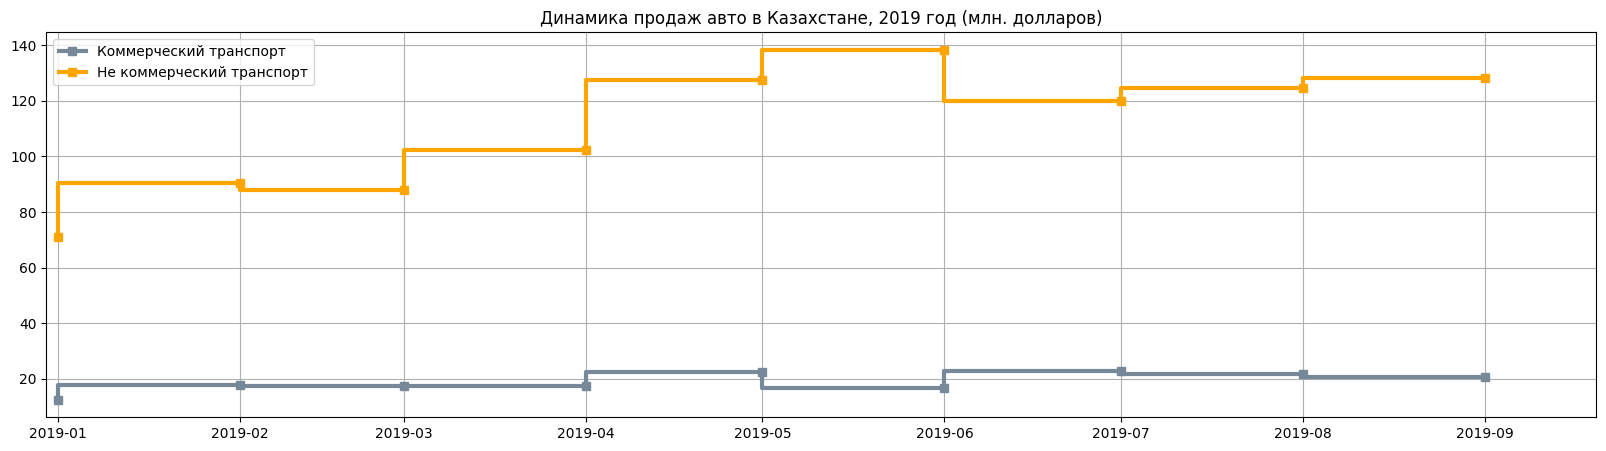

In [ ]:
# посмотрим на то, как изменялись суммы продаж в течении 2019 года (коммерческие/не коммерческие)
plt.figure(figsize=(20, 5))

plt.title('Динамика продаж авто в Казахстане, 2019 год (млн. долларов)')
plt.step(x_tot_comm, y_tot_comm, linewidth=3, marker='s', color='lightslategrey', label='Коммерческий транспорт')
plt.xlim(pd.to_datetime('2018-12-30', format='%Y-%m-%d'), pd.to_datetime('2019-09-20', format='%Y-%m-%d'))

plt.title('Динамика продаж авто в Казахстане, 2019 год (млн. долларов)')
plt.step(x_tot_nocomm, y_tot_nocomm, linewidth=3, marker='s', color='orange', label='Не коммерческий транспорт')
plt.xlim(pd.to_datetime('2018-12-30', format='%Y-%m-%d'), pd.to_datetime('2019-09-20', format='%Y-%m-%d'))

plt.legend()
plt.grid()
plt.show()

####Основные параметры рынка. Выводы

* всего в Казахстане за 2019 год было продано 43962 авто на сумму 1 159 600 568 долларов
* как мы можем видеть, как в количественном так и в денежном отношении авто, проданные для не коммерческих целей в подавляющем большинстве. Всего не коммерческих авто продано в количестве 39067 единиц на сумму 990 млн. долларов, коммерческих авто продано в количестве 4895 единицы на сумму 169 млн. долларов
* среди не коммерческих авто лидируют брэнды Lada	(9618 продаж), Toyota (9374 продажи), Hyundai (5703 продажи). Среди коммерческих - GAZ (2111 продажа), KAMAZ (888 продаж), UAZ (708 продаж). Картина вполне логичная, среди не коммерческих в основном легковые авто популярных брэндов, а среди коммерческих - грузовые авто и минивэны
* общая динамика продаж в количественном отношении с января по сентябрь 2019 года показывает положительную тенденцию. За период январь-мая она изменилась с 3300 до 5500 продаж, затем держится на данном уровне до июля, где проседает до 5300, а после снова возвращается к положительной тенденции и к сентябрю достигает 5700 продаж
* динамика продаж в плоскости категории "коммерция/не коммерция" в количественном отношении выглядит следующим образом. Динамика продаж не коммерческих авто полностью повторяет картину общей, то есть за период с января по май она растет с 300 до 5000, держится на данном уровне до июля, где проседает до 4500, а затем возвращается до прежних значений. А вот динамика продаж коммерческих авто более стабильна. С 250 продаж в январе она плавно растет до 500 в апреле и держится на данном уровне весь 2019 год
* общая динамика продаж в денежном отношении по своей тенденции напоминает динамику в количественном, что собственно логично. А именно с 83 млн. в январе она плавно растет до 150 млн. в мае, далее происходит небольшая просадка до 140 в июле и затем снова возращается к отметке в 150 млн. долларов. Как мы можем видеть на графике с динамикой продаж в денежном отношении в зависимости от категории "коммерческий/не коммерческий", полжительная тенденция в основном происходит за счет продаж не коммерческих авто. Динамика выручки от них с 70 млн. в январе растет до 140 млн. в мае, а затем после небольшой просадки до 120 в июле плвно начинает расти. Выручка же от продаж авто для коммерческих целей на протяжении всего периода держится на уровне 20 млн. долларов
* исходя из картины рынка можно определить, что наиболее активные продажи происходят в летние и осенние месяцы, а самая распростарненная продажа, это продажа авто брэнда Lada для не коммеческих целей  

###RFM-анализ моделей авто

*Для rfm-анализа создадим дополнительный датасет "fm", где отобразим только два наиболее целесообразных в нашем случае параметра: frequency (частота покупок) и monetary (сумма покупок)*

In [ ]:
# создадим копию датасета auto
fm = auto.copy()

In [ ]:
# посчитаем парметры f и m
fm['f_value'] = fm.groupby('model_auto')['count_auto'].transform('sum')
fm['m_value'] = fm.groupby('model_auto')['final_price'].transform('sum')

In [ ]:
# разобьем данные на r, f сегменты
fm['f'] = pd.cut(fm.f_value, 3, labels=[1, 2, 3])
fm['m'] = pd.cut(fm.m_value, 3, labels=[1, 2, 3])

In [ ]:
# теперь выделим столбец с rfm-сегментами
fm['fm'] = fm.f.astype('str') + fm.m.astype('str')

*Дадим описание всех рангов и описание каждого сегмента*

|Ранг|f (частота покупок)|m (сумма покупок)|
|---|---|---|
|1|покупаются редко|низкая маржинальность|
|2|средняя частота покупок|средняя маржинальность|
|3|покупаются часто|высокая маржинальность|

*Как мы можем видеть к примеру, сегмент 11 - это авто с самой низкой маржинальностью, чьи продажи происходят довольно редко, а сегмент 33 напротив представлен авто с самой высокой маржинальностью, чьи продажи происходят наиболее часто. Так же стоит обратить внимание на сегменты 22, 23 и 32*

In [ ]:
# выполним определенные агрегации и опредилим брэнды и модели наиболее интересных авто
fm[fm.fm.isin(['22', '23', '32', '33'])].groupby('brand_auto').model_auto.unique().reset_index()

,brand_auto,model_auto
0,Hyundai,[Tucson]
1,Toyota,"[Camry, LC Prado, RAV4]"


In [ ]:
# теперь взглянем на авто с самым высоким рангом
fm.query('fm == "33"').groupby('brand_auto').model_auto.unique().reset_index()

,brand_auto,model_auto
0,Toyota,[Camry]


*Теперь посмотрим на представителей наиболее интересных сегментов среди коммерческих и некоммерческих авто*

In [ ]:
# определим какие сегменты распространены среди коммерческих авто (модель, бренд)
fm.query('commercial == "коммерция"').groupby('brand_auto').fm.unique().reset_index()

,brand_auto,fm
0,ANKAI,[11]
1,Daewoo,[11]
2,Ford,[11]
3,Foton,[11]
4,GAZ,[11]
5,Hino,[11]
6,Hyundai Truck & Bus,[11]
7,Isuzu,[11]
8,Iveco,[11]
9,Jac,[11]


*Все коммерческие авто имеют самый низкий сегмент "11", то есть это редко покупаемые авто с самой низкой маржинальностью, что отражает вполне реальную картину. Тяжелые грузовики, минивены - довольно специфичная техника и разумеется она не так востребована как лекговые авто*

In [ ]:
# определим какие сегменты распространены среди не коммерческих авто (модель, бренд)
fm.query('commercial == "не коммерция"').groupby('brand_auto').fm.unique().reset_index()

,brand_auto,fm
0,Audi,[11]
1,BMW,[11]
2,Cadillac,[11]
3,Chevrolet,[11]
4,Ford,[11]
5,Hyundai,"[21, 11, 22]"
6,Infiniti,[11]
7,Isuzu,[11]
8,Jac,[11]
9,Jaguar,[11]


*Среди не коммерческих авто стоит выделить брэнд Toyota, некоторые модели которой представлены высокими сегментами "33", "23" (модели "Camry", "RAV4", "LC Prado"), брэнд Hyundai, модель которого "Tucson" представлена сегментом "22"*

####RFM-анализ. Выводы

* по итогу проведенного fm-анализа было получено 7 сегментов, среди которых сегмент "11" наименее интересный (редко продаваемые, низкая маржинальность), "33" наиболее интересный (часто продаваемые, высокая маржинальность). Также можно выделить сегменты "22", "23" и "32" которые указывают или на среднюю маржинальность или на среднюю частоту покупок (первая цифра - частота покупок, вторая - сумма от продаж)
* наиболее высоким сегментом "33" обладает только авто брэнда Toyota модели "Camry"
* к сегментам "22", "23", "32" относятся авто брэнда Hyundai модель "Tucson и авто брэнда Toyota	модели "LC Prado", "RAV4"
* так же можно сказать, что авто, чьи сегменты наиболее высокие, это не коммерческие. Коммерческие же авто (грузовики, минивены) напротив, представлены самым низким сегментом "11"

###Продажи авто в разрезе брэнд/сегмент. Продажи по брэндам и регионам

####Продажи авто в разрезе брэнд/сегмент

In [ ]:
# посмотрим на объем продаж брэнда в зависимости от сегмента
brand_seg = auto.groupby(['brand_auto', 'segment']).final_price.sum().reset_index()

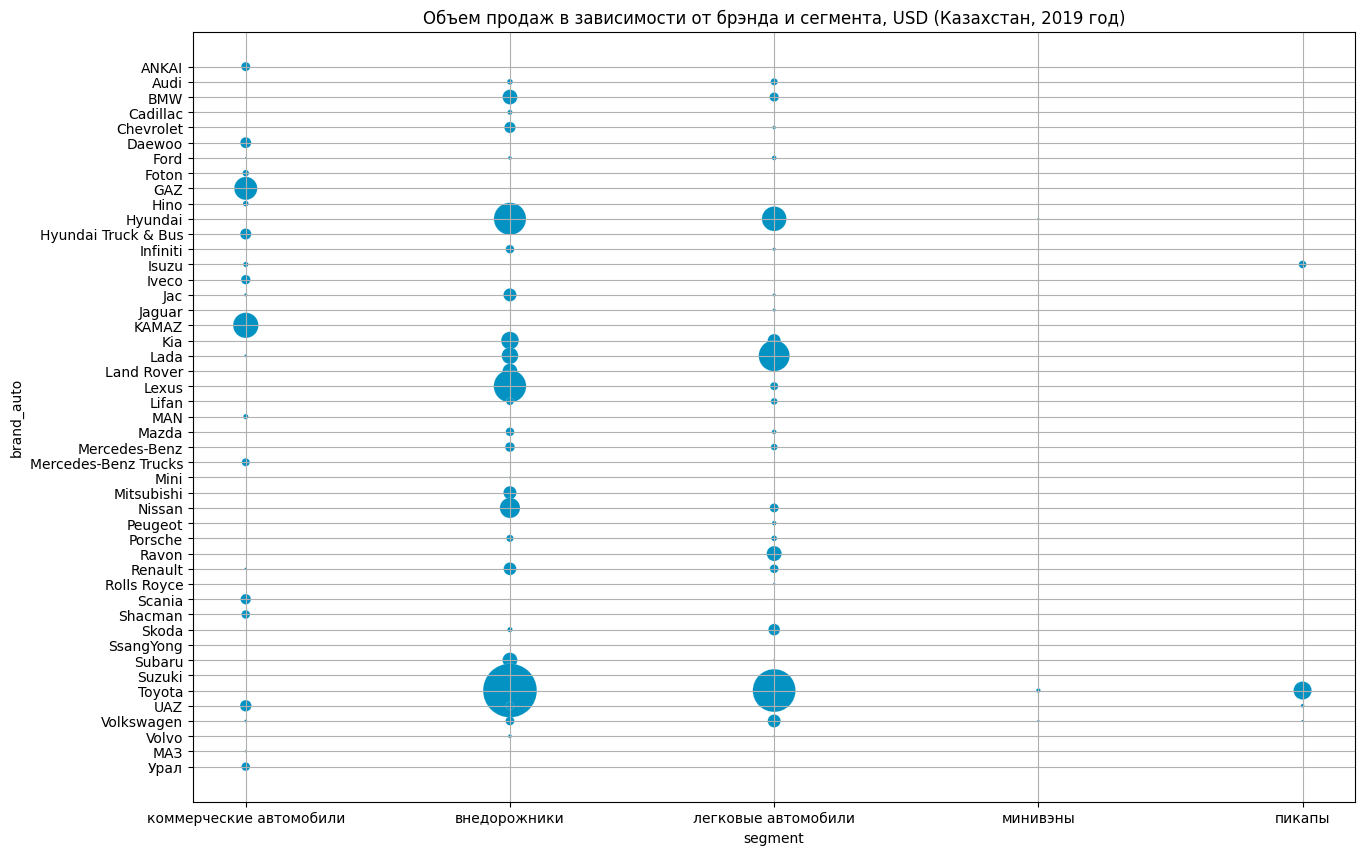

In [ ]:
# визуализируем посредством диаграммы полученные выше данные
plt.figure(figsize=(15, 10))

plt.title('Объем продаж в зависимости от брэнда и сегмента, USD (Казахстан, 2019 год)')

sns.scatterplot(data=brand_seg, x='segment',
                y='brand_auto',
                size='final_price',
                c='#0492C2',
                legend=False,
                sizes=(0, 1500))

plt.grid()
plt.show()

*Среди некоммерческих авто по объему продаж лидируют сегменты "внедорожники", "легковые автомобили" брэнда Toyota. Среди коммерческих, лидерами по объему продаж являются авто брэндов KAMAZ, GAZ*

####Продажи по брэндам

*Посмотрим на результат продаж в денежном отношении в разрезе с разделением на коммерческие и нет, а так же на динамику продаж*

In [ ]:
# агрегируем определенным образом данные для удобства
auto_tot_br = auto.groupby(['brand_auto', 'commercial']).agg({'final_price':sum}).sort_values(by='final_price', ascending=False).reset_index()
auto_tot_br.final_price = round((auto_tot_br.final_price / 1000000), 2) # переведем суммы в млн. долларов

sizes_br = auto_tot_br.final_price.tolist() # для предстоящей визуализации создадим список

In [ ]:
# визуализируем посредством столбчатой диаграммы объем всех продаж в разрезе брэнда (коммерческий/не коммерческий)
plt.figure(figsize=(20, 10))
fig = px.bar(auto_tot_br, x='brand_auto', y='final_price', color='commercial')
fig.update_layout(title = 'Продажи по брэндам в Казахстане. Коммерческие, не коммерческие (млн. долларов)',
                  xaxis_title = 'Брэнды авто',
                  yaxis_title = 'Объем продаж')
fig.show()

<Figure size 2000x1000 with 0 Axes>

*По общему объему брэнды Toyota (лидирует с большим отрывом, продажи около 400 млн.), Hyundai (около 120 млн.), Lada (около 100 млн.) и Lexus (около 90 млн.) превосходят остальные (это только не коммерческие авто). Среди коммерческих заметно лидируют брэнды KAMAZ (100 млн.) и GAZ (90 млн.). Только брэнды UAZ и Isuzu представлены как коммерческие и не коммерческие, но продажи их незначительны (менее 20 млн.)*

####Динамика продаж авто по брэндам

*Посмотрим на то, как развивались продажи брэндов с наибольшими объемами в денежном отношении (коммерческие/не коммерческие). А именно Toyota, Hyundai, Lada, Lexus, KAMAZ и GAZ*

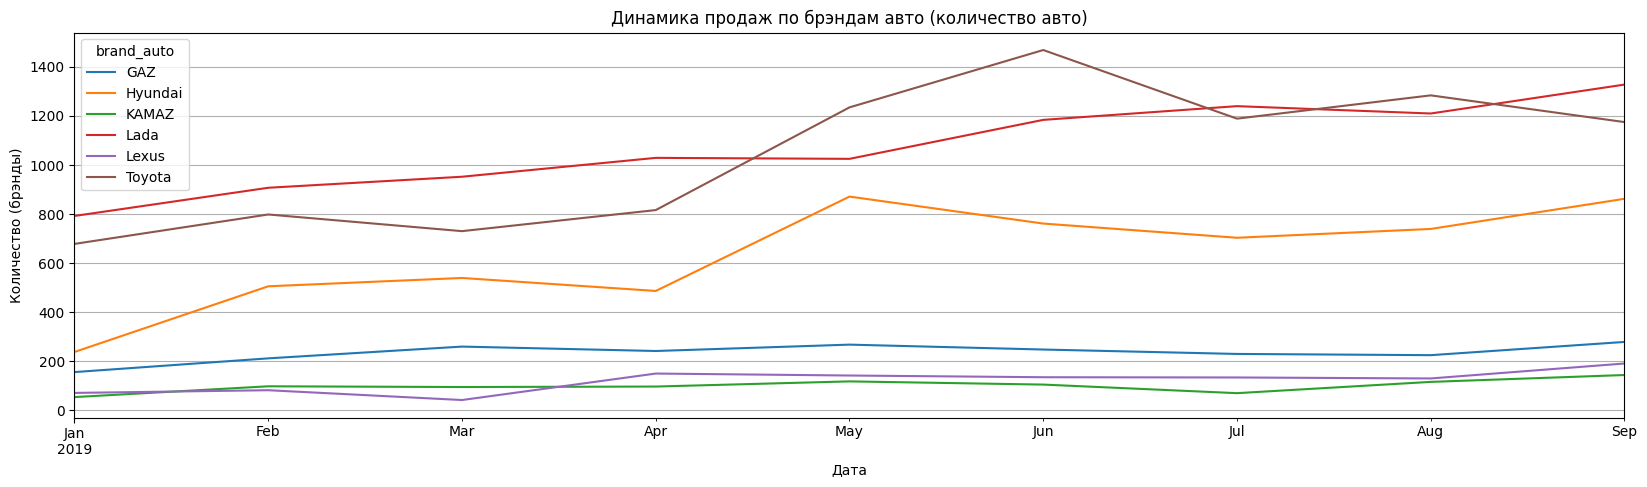

In [ ]:
# далее определим динамику продаж, разбив рынок на брэнды
auto[auto.brand_auto.isin(['Toyota', 'Hyundai', 'Lada', 'Lexus', 'KAMAZ', 'GAZ'])].pivot_table(index='order_date',
                                                                           columns='brand_auto',
                                                                           values='count_auto',
                                                                           aggfunc='sum').plot(grid=True, figsize=(20, 5))
plt.title('Динамика продаж по брэндам авто (количество авто)')
plt.xlabel('Дата')
plt.ylabel('Количество (брэнды)')
plt.show()

*Как мы можем видить, наиболее яркую положительную динамику демострирует Toyota, с января (700 единиц) по июнь (1500 единиц) их продажи выросли практически в два раза, после чего немного просели (1200 единиц), но продолжили держаться на высоком уровне до сентября. Так же можно выделить брэнд Lada и Hyundai, их продажи начиная с января плавно растут на протяжении всего периода, с 800 до 1300 и с 200 до 900 соответственно. А продажи таких брэндов как KAMAZ (100-150 единиц), Lexus (медленный рост со 100 до 200 единиц) и GAZ (медленный рост с 200 до 300 единиц) на протяжении всего периода неизменно держатся практически на одном уровне*

####Продажи авто по регионам

In [ ]:
# определим объем продаж авто в денежном отношении по каждому из регионов и выделим 10-ку наибольших
region_total = auto.groupby('region')['final_price'].sum().sort_values(ascending=False).reset_index().nlargest(10, 'final_price')

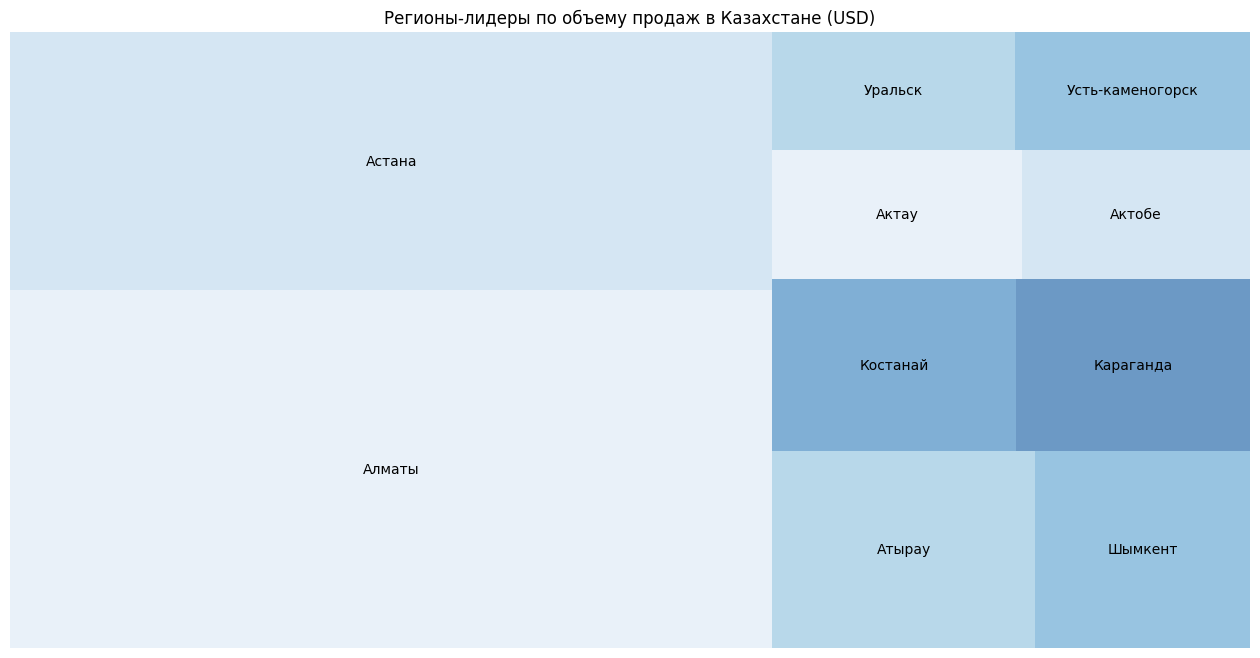

In [ ]:
# визуализируем посредством диаграммы squarify полученные выше данные
plt.figure(figsize=(16, 8))
plt.title('Регионы-лидеры по объему продаж в Казахстане (USD)')
squarify.plot(sizes=region_total['final_price'], label=region_total['region'], alpha=.6, color = sns.color_palette("Blues"))
plt.axis('off')
plt.show()

*Больше всего продаж за период январь-сентябрь 2019 года было произведено в регионе Алматы. Более половины продаж приходится на два региона - Алматы, Астана (что вполне логично, так как это крупнейшие города страны)*

####Продажи авто (брэнд/сегмент, брэнд, регион). Выводы

* среди некоммерческих авто по объему продаж лидируют сегменты "внедорожники", "легковые автомобили" брэнда Toyota. Среди коммерческих, лидерами по объему продаж являются авто брэндов KAMAZ, GAZ
* по общему объему продаж в денежном отношении брэнды Toyota (лидирует с большим отрывом, продажи около 400 млн.), Hyundai (около 120 млн.), Lada (около 100 млн.) и Lexus (около 90 млн.) превосходят остальные (это только не коммерческие авто). Среди коммерческих заметно лидируют брэнды KAMAZ (100 млн.) и GAZ (90 млн.). Только брэнды UAZ и Isuzu представлены как коммерческие и не коммерческие, но продажи их незначительны (менее 20 млн.)
* из упомянутых выше брэндов, наиболее яркую положительную динамику демострирует Toyota, с января (700 единиц) по июнь (1500 единиц) их продажи выросли практически в два раза, после чего немного просели (1200 единиц), но продолжили держаться на высоком уровне до сентября. Так же можно выделить брэнд Lada и Hyundai, их продажи начиная с января плавно растут на протяжении всего периода, с 800 до 1300 и с 200 до 900 соответственно. А продажи таких брэндов как KAMAZ (100-150 единиц), Lexus (медленный рост со 100 до 200 единиц) и GAZ (медленный рост с 200 до 300 единиц) на протяжении всего периода неизменно держатся практически на одном уровне
* в зависимости от региона больше всего продаж за период январь-сентябрь 2019 года было произведено в регионе Алматы. Более половины продаж приходится на два региона - Алматы, Астана (что вполне логично, так как это крупнейшие города страны)

###Формулировка и проверка гипотезы

*В рамках текущей гипотезы установим или опровергнем наличие взаимосвязи стоимости авто и уровня развития региона (средней заработной платы). Официальные данные по средней заработной плате в регионе возьмем на сайте www.stat.gov.kz*

In [ ]:
# создадим словарь с данными по средней заработной плате (тенге)
salary = {
    'г.Алматы': 224158,
    'Костанайская область': 145890,
    'Атырауская область': 351103,
    'г.Астана': 226796,
    'Западно-Казахстанская область': 183914,
    'Восточно-Казахстанская область': 162182,
    'Северо-Казахстанская область': 130233,
    'Павлодарская область': 160670,
    'Акмолинская область': 140272,
    'Мангистауская область': 294099,
    'Карагандинская область': 172239,
    'Актюбинская область': 156595,
    'Южно-Казахстанская область': 110254,
    'Алматинская область': 136212,
    'Кызылординская область': 152085,
    'Жамбылская область': 127043
}

*Создадим дополнительный датасет, где отразим данные об уровне заработной платы в регионе и средней стоимости проданных авто*

In [ ]:
# преобразуем данные с сайта в датасет salary_price
salary_price = pd.DataFrame.from_dict(salary, orient='index', columns=['salary']).reset_index().rename(columns={'index':'state'})

In [ ]:
# возьмем из датасета auto данные о средней стоимости проданных авто
mean_price = auto.groupby('state')['price'].mean().reset_index()

In [ ]:
# объединим два полученных датасета
salary_price = salary_price.merge(mean_price, on='state', how='left')

In [ ]:
# и оценим результат
salary_price

,state,salary,price
0,г.Алматы,224158,34201.226225
1,Костанайская область,145890,24833.557165
2,Атырауская область,351103,26202.454340
3,г.Астана,226796,33581.268422
4,Западно-Казахстанская область,183914,23693.552425
5,Восточно-Казахстанская область,162182,23028.090414
6,Северо-Казахстанская область,130233,23105.424458
7,Павлодарская область,160670,25201.054405
8,Акмолинская область,140272,17037.466742
9,Мангистауская область,294099,30328.741104


*Теперь определим, присутствует ли взаимосвязь между уровнем заработной платы в регионе и средним ценником на авто, проданном в нем. Для этого воспользуемся коэффициентом корреляции Пирсона. Изначально более точно сформулируем гипотезу*

***В качестве нулевой гипотезы H0 мы установим факт, что не существует статистически значимой взаимосвязи между уровнем развития региона и средней стоимостью проданного авто. Тогда в качестве гипотезы H1 установим факт наличия статистически значимой взаимосвязи между уровнем развития региона и средней стоимостью проданного авто***

In [ ]:
# подготовим необходимые массивы данных
x = salary_price.salary
y = salary_price.price

In [ ]:
alpha = 0.05 # установим уровень статистически значимой взаимосвязи
result = stats.pearsonr(x, y) # применим коэффициент корреляции Пирсона

In [ ]:
# выведем результат проверки
print('p-значение:', result[0].round(2))
if result[0] < alpha:
  print('Отвергаем нулевую гипотезу')
else:
  print('Не отвергаем нулевую гипотезу')

p-значение: 0.49
Не отвергаем нулевую гипотезу


####Проверка гипотезы. Выводы

* была сформулирована, а затем проверена следующая гипотеза:

   *Гипотеза H0 - не существует статистически значимой взаимосвязи между уровнем развития региона и средней стоимостью проданного авто*
   
   *Гипотеза H1 - существует статистически значимая взаимосвязь между уровнем развития региона и средней стоимостью проданного авто*

* в результате проверки гипотезы посредством коэффициента корреляции Пирсона была подтверждена нулевая гипотеза H0

###Продажи автоцентов

*Посмотрим на топ-10 компаний Казахстана по объему продаж авто, а так же на динамику их продаж на протяжении периода январь-сентябрь 2019*

In [ ]:
# выполним определенные агрегации
top_comp = auto.groupby('company').final_price.sum().sort_values(ascending=False).reset_index().nlargest(10, 'final_price')
top_comp.final_price = top_comp.final_price/1000000 # упраздним суммы до млн
tp = top_comp.final_price.tolist() # для удобства при визуализации

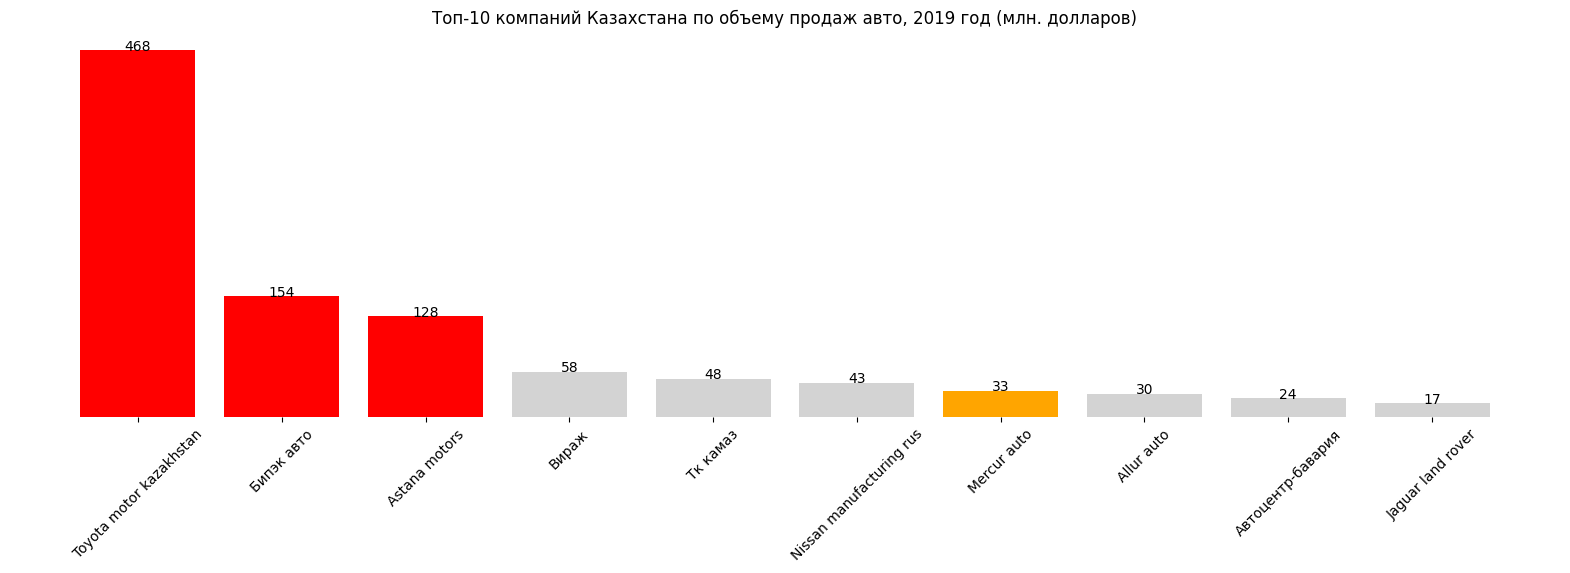

In [ ]:
# визуализируем посредством столбчатой диаграммы
colors = ['lightgray'] * 10
colors[0], colors[1], colors[2], colors[6] = 'red', 'red', 'red', 'orange' # определим цветовую гамму диаграммы

plt.figure(figsize=(20, 5))
plt.bar(top_comp.company, top_comp.final_price, color=colors)

for i in range(len(tp)):
        plt.text(i, tp[i], int(tp[i]), horizontalalignment='center') # добавим подписи над барами

ax = plt.gca ()
ax.get_yaxis().set_visible(False) # исключим ось y

for spine in ['left', 'right', 'bottom', 'top']:
    ax.spines[spine].set_visible(False) # уберем рамки

plt.title('Топ-10 компаний Казахстана по объему продаж авто, 2019 год (млн. долларов)')
plt.xticks(rotation=45)
plt.show()

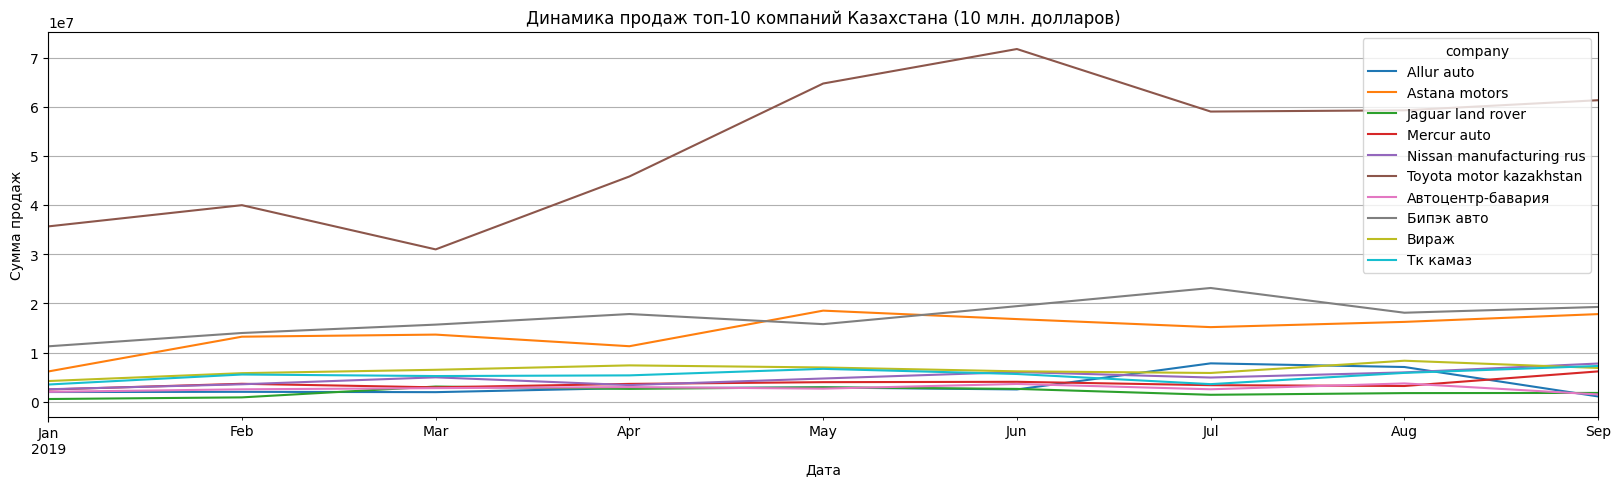

In [ ]:
# теперь посмотрим на динамику продаж компаний, входящих в топ-10 по объему продаж
auto[auto.company.isin(top_comp.company)].pivot_table(index='order_date',
                                                                           columns='company',
                                                                           values='final_price',
                                                                           aggfunc='sum').plot(grid=True, figsize=(20, 5))
plt.title('Динамика продаж топ-10 компаний Казахстана (10 млн. долларов)')
plt.xlabel('Дата')
plt.ylabel('Сумма продаж')
plt.show()

####Продажи автоцентров. Выводы

* среди всех компаний в топ-10 по объему продаж вошли "Toyota motor kazakhstan" (468 млн.), "Бипэк авто" (154 млн.), "Astana motors" (128 млн.), "Вираж" (58 млн.), "Тк камаз" (48 млн.), "Nissan manufacturing rus" (43 млн.), "Mercur auto" (33 млн.), "Allur auto" (30 млн.), "Автоцентр-бавария" (24 млн.) и "Jaguar land rover" (17 млн.). "Toyota motor kazakhstan" (по объему продаж превосходит конкурентов в несколько раз), "Бипэк авто", "Astana motors" представили топ-3 наиболее продающих компаний в Казахстане
* наиболее выраженную тенденцию динамики продаж среди топ-10 компаний по объему продаж можно выделить у компании "Toyota motor kazakhstan" (за полгода рост с 40 млн. до 70), чуть более слабая и плавная тенценция отмечена у компаний "Бипэк авто" (рост с 10 млн. до 20) и "Astana motors" (рост с 7 млн. до 20). Как мы видим у всех топ-3 компаний рост объема продаж вырос практически вдвое. Объемы продаж остальных компаний, входящих в топ-10 держаться на одном уровне без явных тенденций (в диапазоне 1-9 млн.)

###Модели-лидеры на рынке

*Определим топ-10 наиболее продаваемых моделей авто на рынке Казахстана в количественном отношении*

In [ ]:
# выполним определенные агрегации
top_mod = auto.groupby('model_auto').count_auto.sum().sort_values(ascending=False).reset_index().nlargest(10, 'count_auto')
tm = top_mod.count_auto.tolist() # для удобства при визуализации

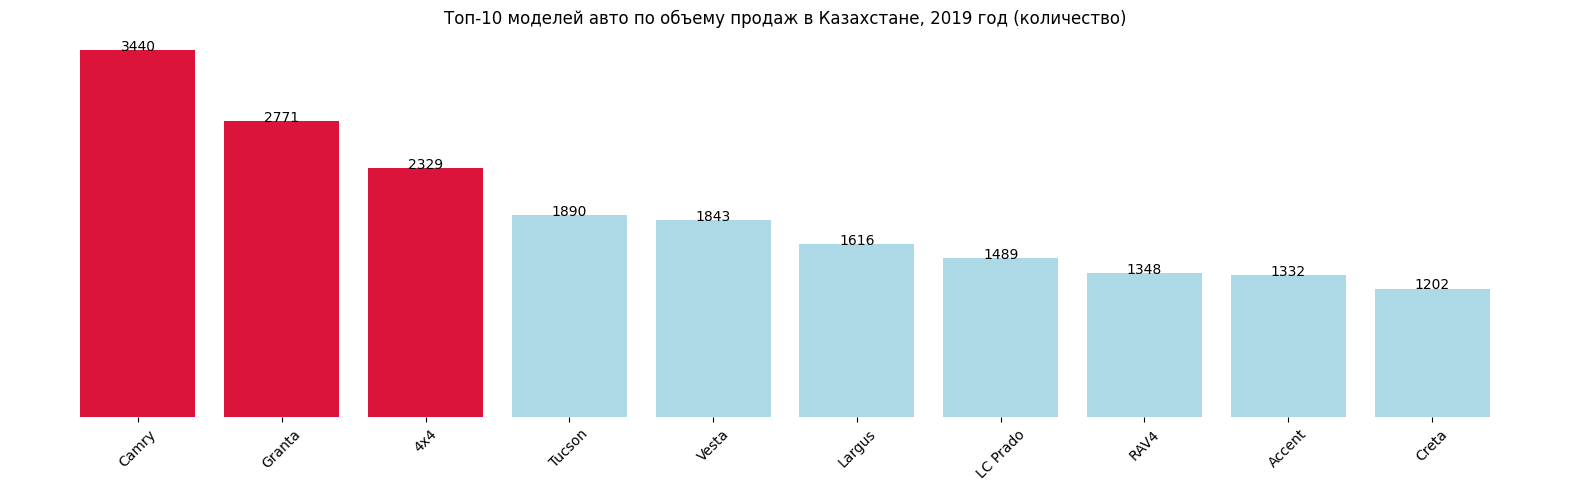

In [ ]:
# визуализируем посредством столбчатой диаграммы
colors = ['lightblue'] * 10
colors[0], colors[1], colors[2] = 'crimson', 'crimson', 'crimson' # определим цветовую гамму диаграммы

plt.figure(figsize=(20, 5))
plt.bar(top_mod.model_auto, top_mod.count_auto, color=colors)

for i in range(len(tm)):
        plt.text(i, tm[i], int(tm[i]), horizontalalignment='center') # добавим подписи над барами

ax = plt.gca ()
ax.get_yaxis().set_visible(False) # исключим ось y

for spine in ['left', 'right', 'bottom', 'top']:
    ax.spines[spine].set_visible(False) # уберем рамки

plt.title('Топ-10 моделей авто по объему продаж в Казахстане, 2019 год (количество)')
plt.xticks(rotation=45)
plt.show()

*Теперь определим топ-10 наиболее продаваемых моделей авто на рынке Казахстана в денежном отношении*

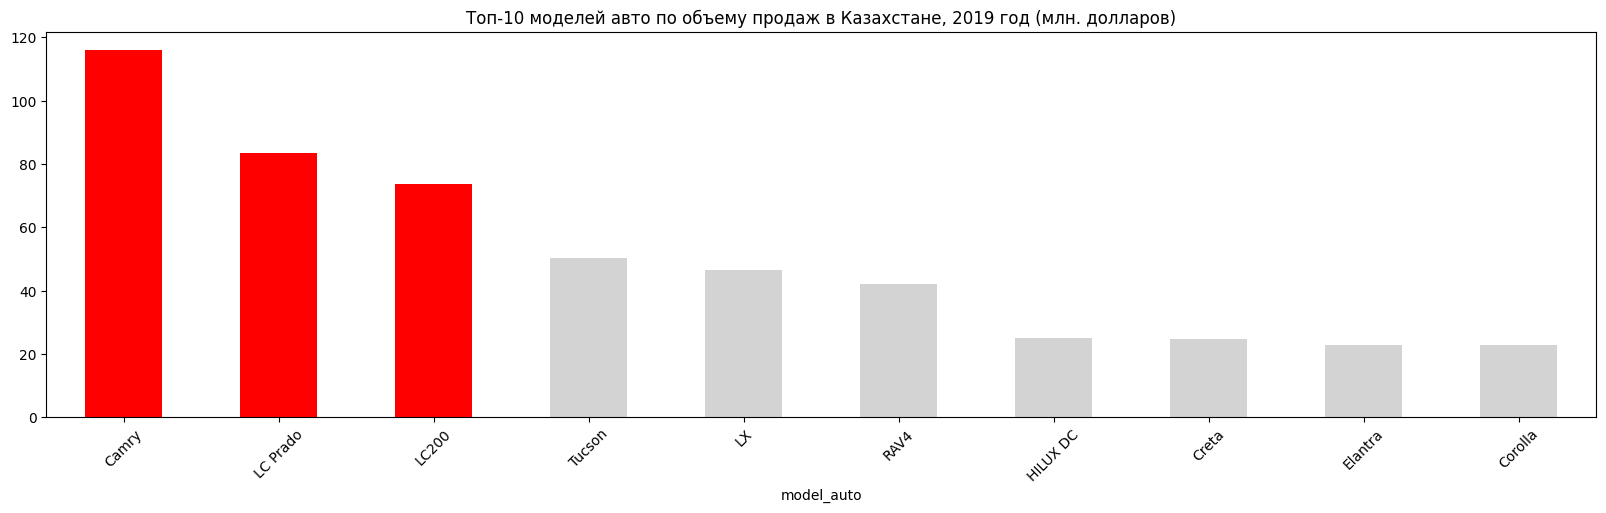

In [ ]:
# аналогично визуализируем посредством столбчатой диаграммы
colors = ['lightgray'] * 10
colors[0], colors[1], colors[2] = 'red', 'red', 'red' # определим цветовую гамму диаграммы

plt.figure(figsize=(20, 5))
(auto.groupby('model_auto')['final_price'].sum().nlargest(10)/1000000).plot(kind='bar', color=colors)
plt.title('Топ-10 моделей авто по объему продаж в Казахстане, 2019 год (млн. долларов)')
plt.xticks(rotation=45)
plt.show()

####Модели-лидеры на рынке. Выводы

* как в количественном (было продано 3440 единиц) так и в денежном (на сумму 120 млн. долларов) неоспоримым лидером среди моделей является Camry
* после Camry по убыванию в количественном отношении топ-10 моделей распределился следующим образом. Granta (2771), 4x4 (2329), Tucson (1890), Vesta (1843), Largus (1616), LC Prado (1489), RAV4 (1348), Accent (1332) и Creta (1202)
* денежном отношении топ-10 распределился иным образом. После Camry следует LC Prado (80 млн.), LC200 (75 млн.), Tucson (50 млн.), LX (50 млн.), RAV4 (40 млн.), HILUX DC, Creta, Elantra, Corolla (по 30 млн.)

###Анализ рынка авто. Основные выводы

* всего в Казахстане за 2019 год было продано 43962 авто на сумму 1 159 600 568 долларов. Как в количественном так и в денежном отношении авто, проданные для не коммерческих целей в подавляющем большинстве. Среди не коммерческих авто лидируют брэнды Lada (9618 продаж), Toyota (9374 продажи), Hyundai (5703 продажи). Среди коммерческих - GAZ (2111 продажа), KAMAZ (888 продаж), UAZ (708 продаж).
* общая динамика продаж в количественном отношении с января по сентябрь 2019 года показывает положительную тенденцию. За период январь-мая она изменилась с 3300 до 5500 продаж, затем держится на данном уровне до июля, где проседает до 5300, а после снова возвращается к положительной тенденции и к сентябрю достигает 5700 продаж (как было установлено, основное влияние на общую картину оказала компания "Toyota motor kazakhstan" и ее продажа 3440 авто брэнда Toyota модель Camry). Для более уверенной оценки динамики рынка авто представленных данных недостаточно (слишком короткий период)
* по итогу проведенного fm-анализа было установлено, что наиболее высоким сегментом обладает только авто брэнда Toyota модель Camry (часто покупают, высокая маржинальность). Так же можно сказать, что авто, чьи сегменты относительно высокие, это не коммерческие (брэнд Hyundai модель Tucson, брэнд Toyota модель LC Prado и RAV4). Коммерческие же авто (грузовики, минивены) напротив, представлены самым низким сегментом (редко покупают, низкая маржинальность)
* среди некоммерческих авто по объему продаж лидируют сегменты "внедорожники", "легковые автомобили" брэнда Toyota. Среди коммерческих, лидерами по объему продаж являются авто брэндов KAMAZ, GAZ
по общему объему продаж в денежном отношении брэнды Toyota (лидирует с большим отрывом, продажи около 400 млн.), Hyundai (около 120 млн.), Lada (около 100 млн.) и Lexus (около 90 млн.) превосходят остальные (это только не коммерческие авто). Среди коммерческих заметно лидируют брэнды KAMAZ (100 млн.) и GAZ (90 млн.).
* наиболее яркую положительную динамику демострирует Toyota, с января (700 единиц) по июнь (1500 единиц) их продажи выросли практически в два раза, после чего немного просели (1200 единиц), но продолжили держаться на высоком уровне до сентября. Так же можно выделить брэнд Lada и Hyundai, их продажи начиная с января плавно растут на протяжении всего периода, с 800 до 1300 и с 200 до 900 соответственно. А продажи таких брэндов как KAMAZ (100-150 единиц), Lexus (медленный рост со 100 до 200 единиц) и GAZ (медленный рост с 200 до 300 единиц) на протяжении всего периода неизменно держатся практически на одном уровне
* по регионам больше всего продаж было произведено в регионе Алматы. Более половины продаж приходится на два региона - Алматы, Астана (что вполне логично, так как это крупнейшие города страны)
* была проверена гипотеза, влияет ли на среднюю стоимость авто уровень развития региона (средний уровень заработной платы). По итогу которой было установлено, что средняя стоимость проданного авто не зависит от уровня развития региона
* среди всех компаний в топ-10 по объему продаж вошли "Toyota motor kazakhstan" (468 млн.), "Бипэк авто" (154 млн.), "Astana motors" (128 млн.), "Вираж" (58 млн.), "Тк камаз" (48 млн.), "Nissan manufacturing rus" (43 млн.), "Mercur auto" (33 млн.), "Allur auto" (30 млн.), "Автоцентр-бавария" (24 млн.) и "Jaguar land rover" (17 млн.). "Toyota motor kazakhstan" (по объему продаж превосходит конкурентов в несколько раз), "Бипэк авто", "Astana motors" представили топ-3 наиболее продающих компаний в Казахстане
наиболее выраженную тенденцию динамики продаж среди топ-10 компаний по объему продаж можно выделить у компании "Toyota motor kazakhstan" (за полгода рост с 40 млн. до 70), чуть более слабая и плавная тенценция отмечена у компаний "Бипэк авто" (рост с 10 млн. до 20) и "Astana motors" (рост с 7 млн. до 20). Как мы видим у всех топ-3 компаний рост объема продаж вырос пратически вдвое. Объемы продаж остальных компаний, входящих в топ-10 держаться на одном уровне без явных тенденций (в диапазоне 1-9 млн.)
* как в количественном, так и в денежном, неоспоримым лидером среди моделей является Camry (3440 авто на 120 млн. долларов). После Camry по убыванию в количественном отношении топ-10 моделей распределился следующим образом. Granta (2771), 4x4 (2329), Tucson (1890), Vesta (1843), Largus (1616), LC Prado (1489), RAV4 (1348), Accent (1332) и Creta (1202). В денежном отношении топ-10 распределился иным образом. После Camry следует LC Prado (80 млн.), LC200 (75 млн.), Tucson (50 млн.), LX (50 млн.), RAV4 (40 млн.), HILUX DC, Creta, Elantra, Corolla (по 30 млн.)

##Анализ положения "Меркур Авто"

###Выручка общая. Ежемесячная выручка. Выручка по брэндам.

In [ ]:
# для удобства сделаем срез данных только касаемо компании "Mercur Auto" в отдельный датасет
mercur_auto = auto.query('company == "Mercur auto"')

In [ ]:
# определим обший размер выручки компании "Mercur Auto"
print('Общая выручка компании "Mercur auto" составляет', mercur_auto.final_price.sum().round(2), 'долларов')
print('Что составляет', (mercur_auto.final_price.sum()\
                         /auto.final_price.sum()*100).round(2), '% от всего рынка Казахстана')
print('Средняя выручка за одну продажу компанией "Mercur auto" составила', mercur_auto.final_price.mean().round(2), 'долларов')

Общая выручка компании "Mercur auto" составляет 33447410.25 долларов
Что составляет 2.88 % от всего рынка Казахстана
Средняя выручка за одну продажу компанией "Mercur auto" составила 35582.35 долларов


In [ ]:
# определим общий объем продаж авто компанией "Mercur Auto" в количественном отношении
print('Всего компанией "Mercur Auto" было продано', mercur_auto.count_auto.sum(), 'авто')
print('Что составляет', (mercur_auto.count_auto.sum()/auto.count_auto.sum()*100).round(2), '% от всего рынка Казахстана')

Всего компанией "Mercur Auto" было продано 1175 авто
Что составляет 2.67 % от всего рынка Казахстана


In [ ]:
# определим размер выручки компании "Mercur Auto" в зависимости от брэнда проданного авто
merc_brand = mercur_auto.groupby('brand_auto')['final_price'].sum().sort_values(ascending=False).reset_index()
merc_brand.final_price = round(merc_brand.final_price/1000000, 2) # преобразуем размер выручки в млн. долларов

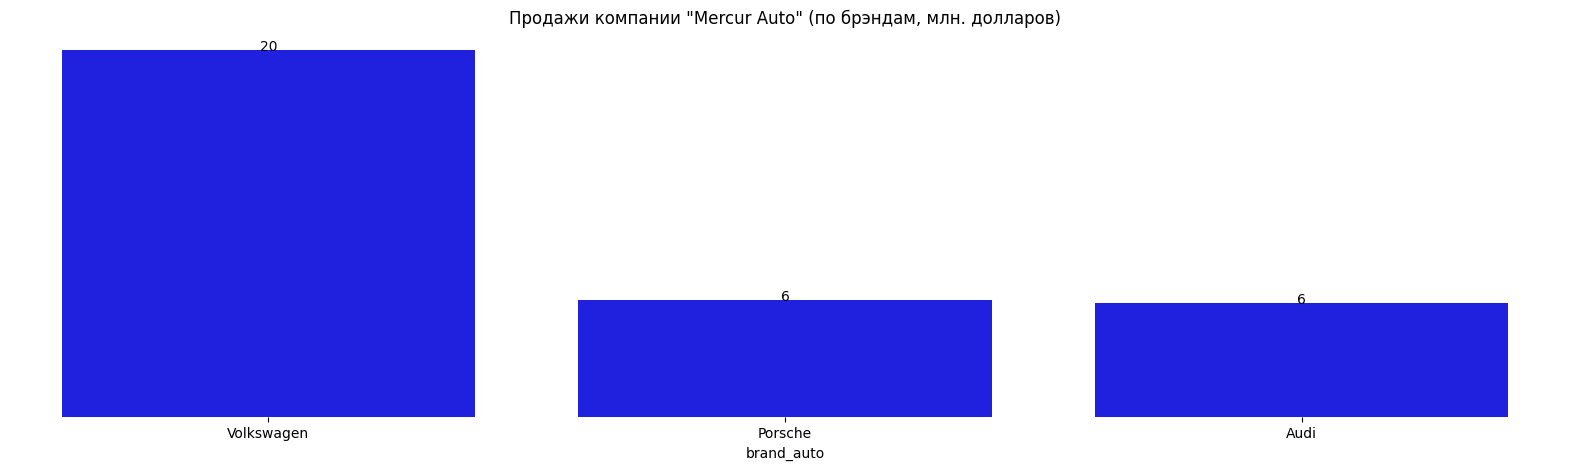

In [ ]:
# визуализируем распределение продаж компании "Mercur auto" по брэндам
plt.figure(figsize=(20, 5))

mc_br = merc_brand.final_price.tolist()
colors = ['blue'] * 3
sns.barplot(merc_brand, x='brand_auto', y='final_price', palette=colors) # построим столбчатую диаграмму

for i in range(len(mc_br)):
        plt.text(i, mc_br[i], int(mc_br[i]), horizontalalignment='center') # добавим подписи над барами

ax = plt.gca ()
ax.get_yaxis().set_visible(False) # исключим ось y

for spine in ['left', 'right', 'bottom', 'top']:
    ax.spines[spine].set_visible(False) # уберем рамки

plt.title('Продажи компании "Mercur Auto" (по брэндам, млн. долларов)')
#plt.xticks(rotation=45)
plt.show()

In [ ]:
# посмотрим на распределение в количественном отношении проданных авто
mercur_auto.groupby('brand_auto').count_auto.sum().sort_values(ascending=False)

brand_auto
Volkswagen    1009
Audi           106
Porsche         60
Name: count_auto, dtype: Int32

*Как мы можем видеть, за период 2019 года, данными за который мы располагаем было продано 1175 авто, 1009 из которых "Volkswagen" (продано на 20 млн.), 106 - "Audi" (продано на 6 млн.) и 60 - "Porsche" (продано на 6 млн.). Картина вполне логичная, так как авто брэндов "Audi" и "Porsche" значительно дороже авто брэнда "Volkswagen"*

In [ ]:
# посмотрим на помесячную выручку компании "Mercur auto"
merc_total = mercur_auto.groupby('order_date').final_price.sum().astype('int').reset_index() # для этого агрегируем по датам данные о продажах
merc_total.order_date = merc_total.order_date.dt.month # упраздним даты до месяца

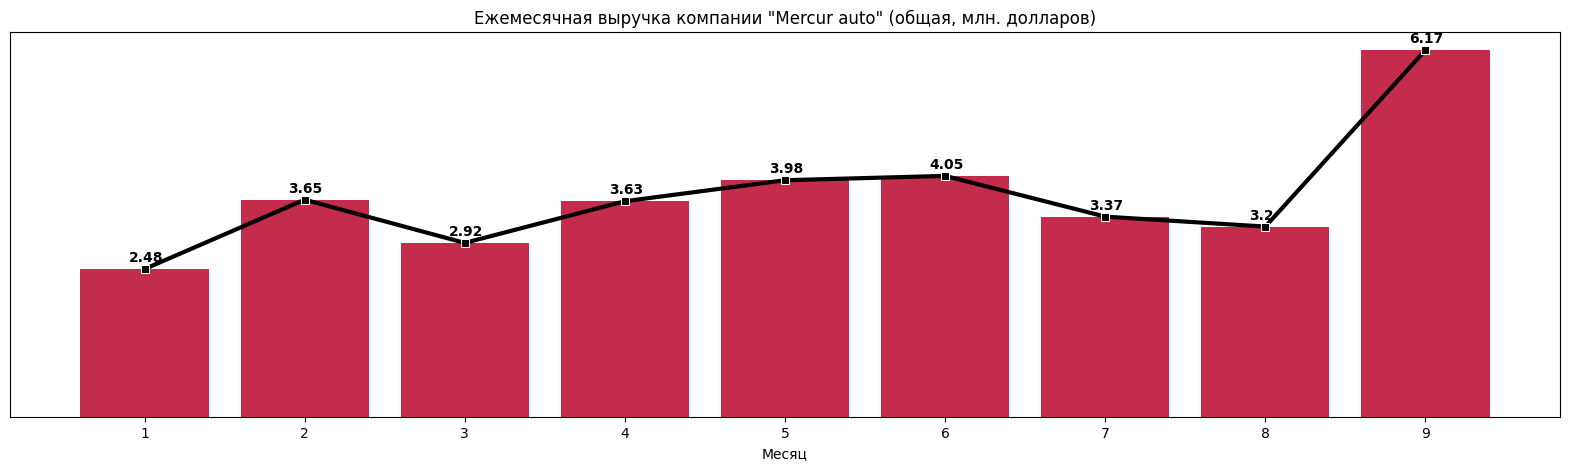

In [ ]:
# визуализируем полученные выше данные
plt.figure(figsize=(20, 5))
plt.title('Ежемесячная выручка компании "Mercur auto" (общая, млн. долларов)')

ax1 = sns.barplot(x=merc_total.order_date, y=merc_total.final_price/1000000, color='crimson')
ax1 = sns.lineplot(merc_total.final_price/1000000, marker='s', color='black', linewidth=3)
plt.xlabel('Месяц')

for x, y, tex in zip(merc_total.order_date, merc_total.final_price/1000000, merc_total.final_price/1000000):
    t = plt.text(x-1.1, y+.2, round(tex, 2),
                 horizontalalignment='left',
                 rotation='horizontal',
                 verticalalignment='center',
                 fontdict={'color':'black', 'weight':'bold'}) # добавим подписи над барами

ax = plt.gca()
ax.get_yaxis().set_visible(False)
plt.show()

*На протяжении периода январь-август объем продаж компании держится близко к уровню 3 млн. долларов в месяц. В сентябре выручка от продаж авто резко возрастает вдвое до 6 млн. долларов*

In [ ]:
# теперь взглянем на продажи компании "Mercur Auto" в разрезе брэндов авто
merc_total_br = mercur_auto.groupby(['brand_auto', 'order_date']).agg({'final_price':'sum'}).sort_values(by='order_date').reset_index()
merc_total_br.order_date = merc_total_br.order_date.dt.month # упраздним даты до месяца
merc_total_br.order_date = merc_total_br.order_date.astype('str')
merc_total_br.final_price = round(merc_total_br.final_price/1000, 2) # упраздним суммы до тыс. долларов

In [ ]:
# создадим словарь с перечнем месяцев для удобства на графике
months = {'1':'January', '2':'February', '3':'March', '4':'April', '5':'May', '6':'June', '7':'July', '8':'August', '9':'September'}

In [ ]:
# заменим циферные обозначения на названия месяцев
merc_total_br.order_date = merc_total_br.order_date.map(months)

In [ ]:
# визуализируем полученные выше данные
plt.figure(figsize=(20, 5))

fig = px.bar(merc_total_br, x='order_date', y='final_price', color='brand_auto')
fig.update_layout(title = 'Ежемесячная выручка компании "Mercur auto" (по брэндам)',
                  xaxis_title = 'Дата',
                  yaxis_title = 'Объем продаж (млн. долларов)')
fig.show()

<Figure size 2000x500 with 0 Axes>

*Исходя из графика выше можно сказать, что чаще всего на объем продаж влияет количество проданных авто брэнда Volkswagen*

####Общая и ежемесячная выручка (по брэндам). Выводы

* совокупная выручка компании "Mercur Auto" от продаж авто за 9 месяцев 2019 года составила 33447410.25 долларов (2.88 % от всего рынка Казахстана). Всего было продано 1175 авто. Средняя выручка за одну продажу составила 35582.35 долларов
* за период 2019 года, данными за который мы располагаем было продано 1009 авто брэнда "Volkswagen" (продано на 20 млн.), 106 - "Audi" (продано на 6 млн.) и 60 - "Porsche" (продано на 6 млн.). Картина вполне логичная, так как авто брэндов "Audi" и "Porsche" значительно дороже авто брэнда "Volkswagen"
* на протяжении периода январь-август объем продаж компании держится близко к уровню 3 млн. долларов в месяц. В сентябре выручка от продаж авто резко возрастает вдвое до 6 млн. долларов (за счет резкого увеличения объема проданных авто брэнда Volkswagen). Вероятно часть авто было куплено с целью пополнения авто-парка какой-либо службы такси

###Продажи по регионам (общие, по брэндам)

*Первоначально посмотрим на то, в каких регионах расположены филиалы компании "Mercur Auto"*

In [ ]:
mercur_auto.state.value_counts()

state
г.Алматы                          458
Атырауская область                122
г.Астана                          112
Костанайская область              107
Карагандинская область             93
Западно-Казахстанская область      34
Южно-Казахстанская область          7
Восточно-Казахстанская область      5
Актюбинская область                 1
Северо-Казахстанская область        1
Name: count, dtype: int64

*Из 17 регионов, филиалы компании "Mercur Auto" расположены в 10. В количестве выше ста филиалов компания представлена в регионе Алматы, Атырауская область, Астана и Костанайская область (логично предположить, что и объемы продаж там можно ожитать выше)*

In [ ]:
# определим объем продаж авто в денежном отношении по регионам (выделим 5 самых прибыльных)
merc_reg_total = mercur_auto.groupby('state').final_price.sum().sort_values(ascending=False).reset_index().nlargest(5, 'final_price')

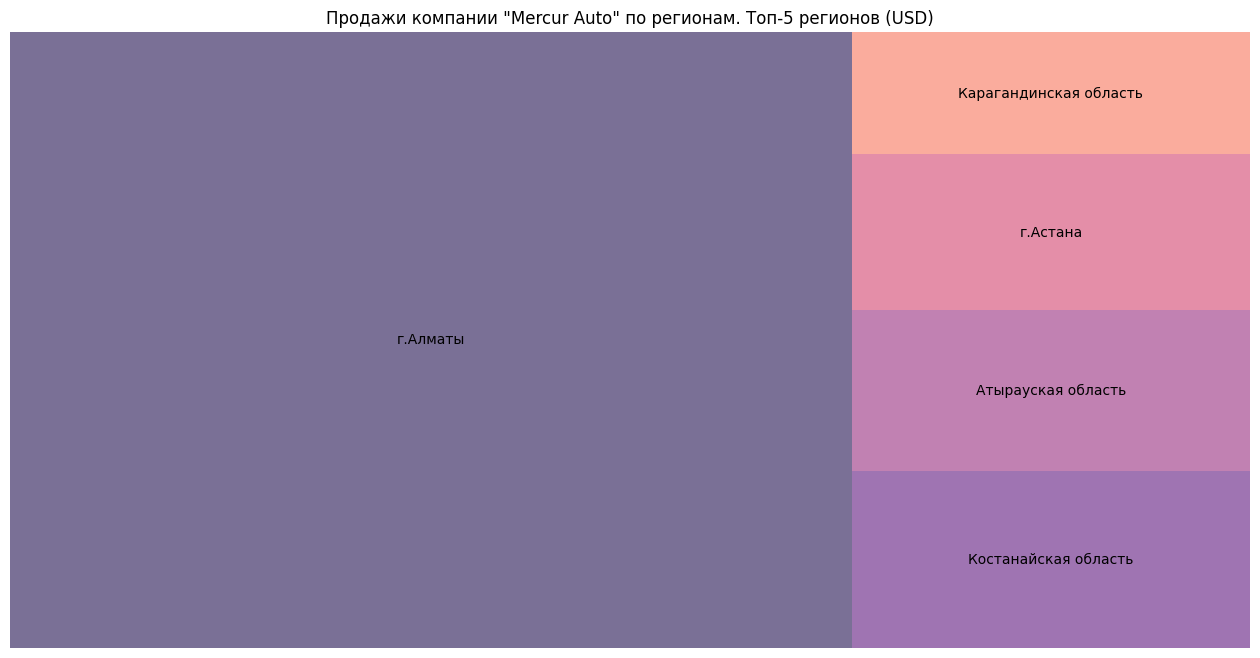

In [ ]:
# визуализируем посредством диаграммы squarify полученные выше данные
plt.figure(figsize=(16, 8))
plt.title('Продажи компании "Mercur Auto" по регионам. Топ-5 регионов (USD)')
squarify.plot(sizes=merc_reg_total['final_price'], label=merc_reg_total['state'], alpha=.6, color = sns.color_palette("magma"))
plt.axis('off')
plt.show()

*Регион Алматы неоспоримый лидер по объему продаж компанией "Mercur Auto" (благодаря 458 салонам, расположенным на территории данного региона). Астана, Костанайская и Атырауская области по продажам практически на одном уровне (численность салонов продаж порядка 100 единиц в каждом из регионов). Карагандинская область замыкает топ по объему продаж (салонов на территории региона менее остальных - 93)*

In [ ]:
# теперь взглянем на продажи компании "Mercur Auto" в разрезе региона и брэндов авто
merc_region_br = mercur_auto.groupby(['brand_auto', 'state']).agg({'final_price':'sum'}).reset_index()

In [ ]:
# визуализируем полученные выше данные
plt.figure(figsize=(20, 5))

fig = px.bar(merc_region_br, x='state', y='final_price', color='brand_auto')
fig.update_layout(title = 'Объем продаж компании "Mercur auto" (по регионам, брэндам)',
                  xaxis_title = 'Регион',
                  yaxis_title = 'Объем продаж (млн. долларов)')
fig.show()

<Figure size 2000x500 with 0 Axes>

*Как мы видим, практически во всех регионах в основе продаж лежит авто брэнда "Volkswagen". В Астане, Костанайской и Атырауской областях присутствует небольшая доля проданных авто брэнда "Audi". Заметно выделяется Алматы, единственный регион, в котором столь значительная доля продаваемых авто брэндов "Audi", "Porsche" и "Volkswagen"*

####Продажи по регионам. Выводы

* из 17 регионов, филиалы компании "Mercur Auto" расположены в 10
* Алматы неоспоримый лидер по объему продаж компанией "Mercur Auto" (458 салонов на территории данного региона). Астана, Костанайская и Атырауская области по продажам практически на одном уровне (около 100 единиц в каждом из регионов). Карагандинская область замыкает топ по объему продаж (93 салона)
* практически во всех регионах в основе продаж лежит авто брэнда "Volkswagen". В Астане, Костанайской и Атырауской областях присутствует небольшая доля проданных авто брэнда "Audi". Выделяется Алматы, единственный регион, в котором столь занчительная доля продаваемых авто брэндов "Audi", "Porsche" и "Volkswagen"

###Конкурентный анализ

*Посмотрим на то, какие компании-конкуренты есть в тех же регионах, в которых работает "Mercur Auto"*

In [ ]:
# посмотрим, сколько всего филиалов компании "Mercur Auto" в стране
print('Всего на территории всех регионов', auto.query('company == "Mercur auto"').company.count(), 'филиалов компании "Mercur Auto"')

Всего на территории всех регионов 940 филиалов компании "Mercur Auto"


In [ ]:
# сохраним регионы, в которых есть "Mercur Auto"
rg_mr = mercur_auto.state.unique().tolist()

In [ ]:
# посмотрим на то, сколько компаний присутствует на рынке в тех же регионах
auto[(auto.state.isin(rg_mr)) & (auto.company != 'Mercur auto')].groupby('state')['company'].nunique().sort_values(ascending=False)

state
г.Алматы                          29
г.Астана                          21
Карагандинская область            19
Костанайская область              19
Атырауская область                18
Восточно-Казахстанская область    15
Западно-Казахстанская область     15
Актюбинская область               14
Южно-Казахстанская область        14
Северо-Казахстанская область      10
Name: company, dtype: int64

In [ ]:
# и то, сколько филиалов "Mercur Auto" в том или ином регионе
auto[auto.company == 'Mercur auto'].groupby('state')['company'].count().sort_values(ascending=False)

state
г.Алматы                          458
Атырауская область                122
г.Астана                          112
Костанайская область              107
Карагандинская область             93
Западно-Казахстанская область      34
Южно-Казахстанская область          7
Восточно-Казахстанская область      5
Актюбинская область                 1
Северо-Казахстанская область        1
Name: company, dtype: int64

*Как мы видим наибольшая конкуренция в тех регионах, где самые высокие объемы продаж у компании "Mercur Auto" в том числе. Больше всего филиалов "Mercur Auto" в Алматы (458), затем по убыванию Атфрауская область (122), Астана (112), Костанайская область (107), Карагандинская область (93), Западно-Казахстанская область (34), Южно-Казахстанская область (7), Восточно-Казахстанская область (5) и по одному филиалу в Актюбинской и Северо-Казахстанской областях*

*Взглянем на те компании, что занимаются продажей тех же брэндов авто, что и компания "Mercur Auto" (которые в том числе расположены на территории тех же регионов)*

In [ ]:
# посмотрим на то, какие компании продают авто в тех же регионах и тех же самых брэндов
auto[(auto.state.isin(rg_mr)) & (auto.brand_auto == "Volkswagen")].company.unique()

array(['Mercur auto'], dtype=object)

In [ ]:
auto[(auto.state.isin(rg_mr)) & (auto.brand_auto == "Audi")].company.unique()

array(['Mercur auto'], dtype=object)

In [ ]:
auto[(auto.state.isin(rg_mr)) & (auto.brand_auto == "Porsche")].company.unique()

array(['Mercur auto'], dtype=object)

*Как мы видим, продажей авто брэндов "Volkswagen", "Audi" и "Porsche" в данных регионах занимается только компания "Mercur Auto". Следовательно явных конкурентов у компании нет*

*Далее посмотрим на то, какие компании в данных регионах лидируют по продажам*

In [ ]:
# определим лидеров по продажам и то, на каком месте компания "Mercur Auto (млн. долларов)"
auto[auto.state.isin(rg_mr)].groupby('company').final_price.sum().sort_values(ascending=False).head(10)/1000000

company
Toyota motor kazakhstan     415.503413
Бипэк авто                  124.122846
Astana motors               115.193000
Вираж                        46.507334
Nissan manufacturing rus     42.022510
Тк камаз                     40.754103
Mercur auto                  33.447410
Allur auto                   26.975189
Автоцентр-бавария            24.283575
Jaguar land rover            17.325091
Name: final_price, dtype: float64

*Неоспоримыми лидерами продаж являются компании "Toyota motor kazakhstan" (415 млн), "Бипэк авто" (124 млн.) и "Astana motors" (115 млн.). Их выручка превышает размер 100 млн долларов*

*Теперь посмотрим на то, к авто каких сегментов, классов относятся те, что продает "Mercur Auto" и компании лидеры по продажам*

In [ ]:
# посмотрим, к каким сегментам и классам относятся авто, продаваемые компанией "Mercur Auto"
mr_seg_cl = mercur_auto.groupby(['segment', 'class_2013']).agg({'final_price':'sum'}).reset_index()

In [ ]:
# визуализируем полученные выше данные
plt.figure(figsize=(20, 5))

fig = px.bar(mr_seg_cl, x='segment', y='final_price', color='class_2013')
fig.update_layout(title = 'Объемы продаж компании "Mercur auto" (по сегментам, классам)',
                  xaxis_title = 'Сегмент',
                  yaxis_title = 'Объем продаж')
fig.show()

<Figure size 2000x500 with 0 Axes>

*В основе продаж находятся авто сегмента "легковые", основная часть которых отностися к классу "b" (таких авто было продано на 10 млн. долларов). Так же можно выделить сегмент "внедорожники" таких классов как "компактные suv" (продано на 6.2 млн.) и "стандартные suv" (продано на 4.6 млн.)*

In [ ]:
# сохраним наименования компаний-лидеров и классы авто, которые лидеры продаж у "Mercur Auto"
top_comp = ['Toyota motor kazakhstan', 'Бипэк авто', 'Astana motors']
top_cl = ['b class', 'компактные suv', 'стандартные suv']

*Посмотрим на авто каких брэндов и моделей (сегменты "легковые", "внедорожники", классы "class-b", "стандартный suv", "компактный suv") продают лидирующие компании-конкуренты (то есть потенциальные конкуренты)*

In [ ]:
# выполним срез и взглянем на брэнд и модели авто, которые обеспечили лидирующие позиции компаниям топ-3
comp_top_mod = auto[(auto.company.isin(top_comp)) & (auto.class_2013.isin(top_cl))]\
.groupby(['company','model_auto']).final_price.sum().sort_values(ascending=False).reset_index()

<Axes: title={'center': 'Модели-лидеры продаж компаний-конкурентов (целевые классы)'}, xlabel='company', ylabel='model_auto'>

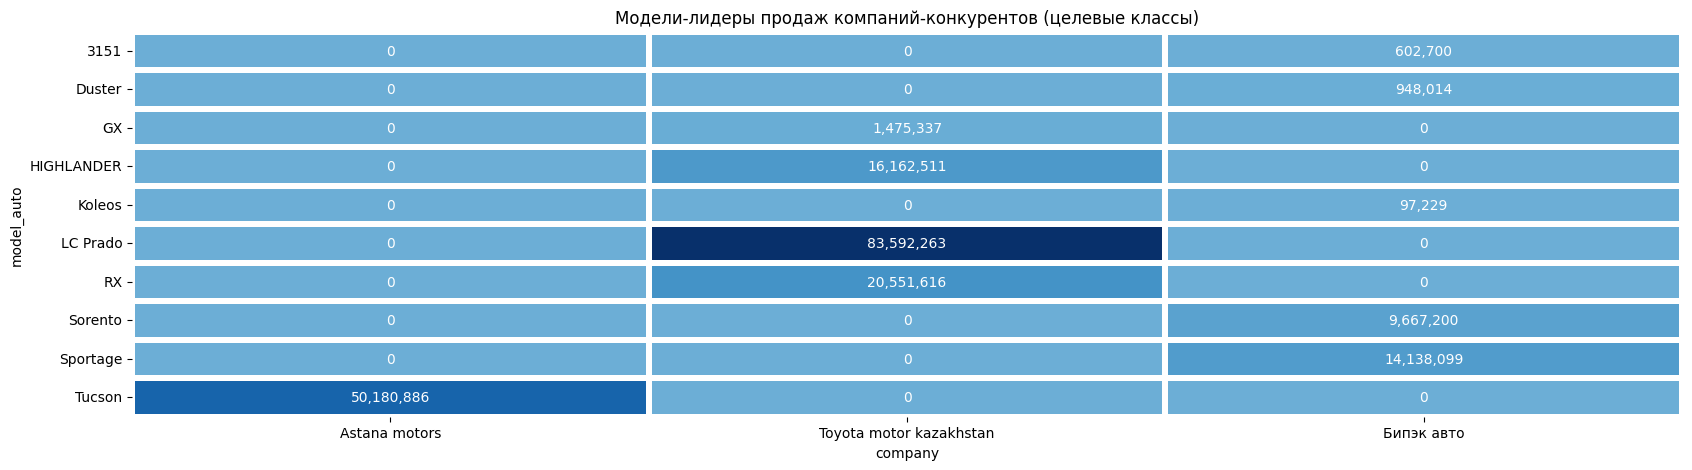

In [ ]:
# визуализируем полученные выше данные
top_mod_sell = (
    pd.pivot_table(comp_top_mod, index='model_auto', columns='company', values='final_price').fillna(0).astype('int')
)

plt.figure(figsize=(20, 5))
plt.title('Модели-лидеры продаж компаний-конкурентов (целевые классы)')
sns.heatmap(top_mod_sell, annot=True, cbar=False, cmap='Blues', fmt=',.0f', center=600000, vmin=0, linewidth=3)

*Особенно можно выделить авто брэнда Toyota, моделей "LC Prado" (продано компанией "Toyota motor Kazakhstan" на 83 млн. долларов) и "HIGHLANDER" (продано той же компанией на 16 млн. долларов), Hyundai модели "Tucson" (продано компанией "Astana motors" на 50 млн. долларов), Lexus модели "RX" (продано компанией "Toyota motor Kazakhstan" на 20 млн. долларов) и Kia модели "Sportage" (продано компанией "Бипэк авто" на 14 млн. долларов). Авто данных брэндов и моделей (относятся к тем же сегментам и классам, что приносят наибольшую прибыль компании "Mercur Auto") являются лидерами продаж у компаний, которые расположены на территории тех же регионов, что и компания "Mercur Auto", общие объемы которых составляют топ-3 по продажам от остальных компаний*

####Конкурентный анализ. Выводы

* всего на территории всех регионов расположено 940 филиалов компании "Mercur Auto"
* наибольшая конкуренция (количество филиалов других компаний) в тех регионах, где самые высокие объемы продаж у компании "Mercur Auto" в том числе (Алматы, Астана)
* больше всего филиалов "Mercur Auto" в Алматы (458), затем по убыванию Атфрауская область (122), Астана (112), Костанайская область (107), Карагандинская область (93), Западно-Казахстанская область (34), Южно-Казахстанская область (7), Восточно-Казахстанская область (5) и по одному филиалу в Актюбинской и Северо-Казахстанской областях
* компания "Mercur Auto" является монополистом на рынке таких брэндов как "Volkswagen", "Audi" и "Porsche"
* "Toyota motor kazakhstan" (продажи 415 млн), "Бипэк авто" (продажи 124 млн.) и "Astana motors" (продажи 115 млн.). Эти компании являются непосредственными конкурентами, так как они расположены на территории тех же регионов и их выручка превышает выручку компании "Mercur Auto"
* в основе продаж компании "Mercur Auto" находятся авто сегмента "легковые", основная часть которых отностися к классу "b" (таких авто было продано на 10 млн. долларов). Так же можно выделить сегмент "внедорожники" таких классов как "компактные suv" (продано на 6.2 млн.) и "стандартные suv" (продано на 4.6 млн.)
* среди моделей-лидеров продаж компаний-конкуретнов, которые относятся к целевым сегментам (составляются основу продаж компании "Mercur Auto") можно выделить авто брэнда Toyota, моделей "LC Prado" (продано компанией "Toyota motor Kazakhstan" на 83 млн. долларов) и "HIGHLANDER" (продано той же компанией на 16 млн. долларов), Hyundai модели "Tucson" (продано компанией "Astana motors" на 50 млн. долларов), Lexus модели "RX" (продано компанией "Toyota motor Kazakhstan" на 20 млн. долларов) и Kia модели "Sportage" (продано компанией "Бипэк авто" на 14 млн. долларов)

###BCG анализ (анализ продаж по моделям)

*Первоначально подготовим соответствующий датасет, а затем применим его для создания матрицы и оценим относительную долю каждой модели на рынке и темп их продаж*

In [ ]:
# агрегируем данные по модели и дате продажи
bcg_auto = mercur_auto.groupby(['model_auto', 'order_date']).final_price.sum().reset_index()

In [ ]:
# добавим поле с долей каждой модели на рынке
bcg_auto['per_of_total'] = bcg_auto.groupby('model_auto').final_price.transform('sum') / bcg_auto.final_price.sum() * 100

In [ ]:
# добавим поле с показателем темпа продаж
bcg_auto['grow'] = bcg_auto.groupby('model_auto').final_price.transform('last')\
 / bcg_auto.sort_values(by='order_date').groupby('model_auto').final_price.transform('first') * 100

In [ ]:
# добавим поле с общей выручкой по моделям
bcg_auto['total'] = bcg_auto.groupby('model_auto').final_price.transform('sum')

In [ ]:
# взглянем на результат
bcg_auto.sample(4)

,model_auto,order_date,final_price,per_of_total,grow,total
113,Transporter Kasten,2019-01-01,34694.489310,1.873450,210.493568,6.266205e+05
99,Tiguan,2019-04-01,509291.708753,16.542214,188.736447,5.532942e+06
39,Jetta,2019-03-01,257113.587524,7.202139,186.908385,2.408929e+06
13,A6,2019-06-01,102740.323256,7.182038,28.240162,2.402206e+06


*Построим матрицу BCG*

In [ ]:
color_scheme = ["#0492C2"] * 11
color_scheme[1], color_scheme[3], color_scheme[5], color_scheme[6] = '#FCAE1E', '#FCAE1E', '#FCAE1E', '#FCAE1E'

fig = px.scatter(bcg_auto[bcg_auto.per_of_total > 1.2], # исключим самые слабые модели
                 x="per_of_total", y="grow",
                 size="total", color="model_auto",
                 size_max=75,
                 text='model_auto',
                 color_discrete_sequence=color_scheme,
                 title="BCG матрица (Mercur Auto)",
                 width=1000, height=600)

# добавим квадранты матрицы
fig.add_shape(type='line', x0=0, y0=400, x1=38, y1=400, line=dict(color='black', dash='dash', width=3))
fig.add_shape(type='line', x0=20, y0=0, x1=20, y1=800, line=dict(color='black', dash='dash', width=3))

# добавим подписи квадртантов
fig.add_annotation(x=18, y=50, text="<b>Собаки</b>", showarrow=False)
fig.add_annotation(x=16.5, y=450, text="<b>Проблемные дети</b>", showarrow=False)
fig.add_annotation(x=36, y=450, text="<b>Звезды</b>", showarrow=False)
fig.add_annotation(x=34.5, y=50, text="<b>Дойные коровы</b>", showarrow=False)

# уберем легенду
fig.update_layout(showlegend=False, xaxis_title="Доля на рынке, %", yaxis_title="Изменение объема продаж, %")

fig.show()

####BCG анализ. Выводы

* категория "звезды" представлена только авто брэнда Volkswagen, модели Polo. Продажи данного авто уже приносят значительную часть прибыли и потенциально имеют перспективы к большему росту. Необходимо сделать акцент на продажах данного авто, вероятно организовать дополнительные поставки, для перехода в категорию "дойные коровы"
* категория "проблемные дети" представлена авто брэнда Audi, модели Q5. Данные авто пока не приносят заметной прибыли, но если направить больше маркетинговых усилий и более активно предлагать данный продукт, то потенциально он может перейти в категорию "звезды"
* категория "Собаки" наиболее массовая и представлена авто брэнда Porsche, модели Cayenne, Panamera, Macan, брэнда Volkswagen, модели Jetta, Tiguan, Passat, Amarok, Touareg, Transporter Kasten, брэнда Audi, модели A6, A8, Q7. Их продажи не особо затратны, но в то же время не приносят ощутимой прибыли, следовательно не перспективны. Поставки основной части этих авто следует свести к минимуму, так же вероятно стоит перепозиционировать стратегию продаж авто брэнда Volkswagen, модели Tiguan

###Положение "Меркур Авто". Основные выводы

* совокупная выручка компании "Mercur Auto" от продаж авто за 9 месяцев 2019 года составила 33447410.25 долларов, что составляет 2.88 % рынка Казахстана. Было продано 1175 авто, в среднем по цене 35582.35 долларов. В основном были проданы авто брэнда "Volkswagen" (на 20 млн.), "Audi" (на 6 млн.) и "Porsche" (на 6 млн.)
* филиалы компании "Mercur Auto" расположены в 10 регионах Казахстана. Алматы неоспоримый лидер по объему продаж компанией "Mercur Auto" (458 салонов на территории данного региона). Астана, Костанайская и Атырауская области по продажам практически на одном уровне (около 100 единиц в каждом из регионов). Карагандинская область замыкает топ по объему продаж (93 салона). Так же Алматы - единственный регион, в котором столь значительная доля продаваемых авто брэндов "Audi", "Porsche" и "Volkswagen". Всего компания "Mercur Auto" представлена в количестве 940 филиалов
* наибольшая конкуренция в Алматы и Астана. Компания "Mercur Auto" является монополистом на рынке таких брэндов как "Volkswagen", "Audi" и "Porsche". Компании "Toyota motor kazakhstan", "Бипэк авто" и "Astana motors" являются непосредственными конкурентами, так как они расположены на территории тех же регионов и их выручка превышает выручку компании "Mercur Auto"
* в основе продаж компании "Mercur Auto" находятся авто сегмента "легковые" (class b), "внедорожники" (компактные suv, стандартные suv). Среди моделей-лидеров продаж компаний-конкурентов, которые относятся к целевым сегментам "Mercur Auto" можно выделить авто брэнда Toyota, моделей "LC Prado" и "HIGHLANDER", Hyundai модели "Tucson", Lexus модели "RX" и Kia модели "Sportage"
* в рамках построенной BCG-матрицы, категория "звезды" представлена только авто брэнда Volkswagen, модели Polo. Продажи данного авто уже приносят значительную часть прибыли и потенциально имеют перспективы к большему росту. Необходимо сделать акцент на продажах данного авто, вероятно организовать дополнительные поставки, для перехода в категорию "дойные коровы". Категория "проблемные дети" представлена авто брэнда Audi, модели Q5. Данные авто пока не приносят заметной прибыли, но если направить больше маркетинговых усилий и более активно предлагать данный продукт, то потенциально он может перейти в категорию "звезды". И категория "Собаки" наиболее массовая и представлена авто брэнда Porsche, модели Cayenne, Panamera, Macan, брэнда Volkswagen, модели Jetta, Tiguan, Passat, Amarok, Touareg, Transporter Kasten, брэнда Audi, модели A6, A8, Q7. Их продажи не особо затратны, но в то же время не приносят ощутимой прибыли, следовательно не перспективны. Поставки основной части этих авто следует свести к минимуму, так же вероятно стоит перепозиционировать стратегию продаж авто брэнда Volkswagen, модели Tiguan. Категория "дойные коровы" и вовсе отсутствует

#Общие выводы. Рекомендации

* наиболее популярными брэндами в Казахстане являются Toyota и Hyundai (модели "Camry", "Tucson", "LC Prado", "RAV4", "Accent"). Основным спросом пользуются относительно новые авто 2018 года выпуска, с бензиновым двигателем
объема 1.6 литра и автоматической коробкой передач, сегмента "легковые" или "внедорожники", класса "class b", "компактный suv"
* средняя цена проданных авто - 29738 долларов. Как мы видим по сравнению с зимним, в летний период потребительский спрос находится на своих пиковых отметках, что соответствует действительности
* в следствии проведенного fm-анализа было установлено, что наиболее высоким сегментом обладает только авто брэнда Toyota модель Camry (часто покупают, высокая маржинальность). Так же можно сказать, чьи сегменты относительно высокие. Это брэнд Hyundai модель Tucson, брэнд Toyota модель LC Prado и RAV4
* по продажам по регионам больше всего было произведено в Алматы. Более половины продаж приходится на два региона - Алматы, Астана (что вполне логично, так как это крупнейшие города страны). По итогу проверки гипотезы, влияет ли на среднюю стоимость авто уровень развития региона (средний уровень заработной платы) было установлено, что средняя стоимость проданного авто не зависит от уровня развития региона
* среди всех компаний в топ-10 по объему продаж вошли "Toyota motor kazakhstan", "Бипэк авто", "Astana motors", "Вираж", "Тк камаз", "Nissan manufacturing rus", "Mercur auto", "Allur auto", "Автоцентр-бавария" и "Jaguar land rover". "Toyota motor kazakhstan" (по объему продаж превосходит конкурентов в несколько раз), "Бипэк авто", "Astana motors" представили топ-3 наиболее продающих компаний в Казахстане
* совокупная выручка компании "Mercur Auto" от продаж авто за 9 месяцев 2019 года - 33447410.25 долларов (2.88 % рынка Казахстана). Всего компания "Mercur Auto" представлена в количестве 940 филиалов, которые расположены в 10 регионах Казахстана. Алматы неоспоримый лидер по объему продаж компанией "Mercur Auto" и количеству салонов. Так же Алматы - единственный регион, в котором столь значительная доля продаваемых компанией авто брэндов "Audi", "Porsche" и "Volkswagen" ("Mercur Auto" - монополист на рынке брэндов "Volkswagen", "Audi" и "Porsche"). Компании "Toyota motor kazakhstan", "Бипэк авто" и "Astana motors" являются непосредственными конкурентами, так как они расположены на территории тех же регионов, их выручка превышает выручку компании "Mercur Auto" и в основе их продаж есть авто аналогичного сегмента и класса (Toyota, моделей "LC Prado" и "HIGHLANDER", Hyundai модели "Tucson", Lexus модели "RX" и Kia модели "Sportage")
* поставки авто брэндов Porsche (Cayenne, Panamera, Macan), Volkswagen (Jetta, Tiguan, Passat, Amarok, Touareg, Transporter Kasten), Audi (A6, A8, Q7) следует свести к минимуму, так как они не приносят ощутимой прибыли, следовательно не перспективны. А в отношении авто брэнда Volkswagen модели Tiguan вероятно стоит перепозиционировать стратегию продаж. Продажи авто брэнда Audi, модели Q5 пока не приносят заметной прибыли, но если направить больше маркетинговых усилий и более активно предлагать данный продукт, то это можно исправить. А наибольшую прибыль компании "Mercur Auto" приносят продажи авто брэнда Volkswagen, модели Polo. Необходимо сделать акцент на продажах данного авто, вероятно организовать дополнительные поставки
* рекомендации:
  * снизить поставки и маркетинговые усилия направленные на сбыт авто брэндов Porsche (Cayenne, Panamera, Macan), Volkswagen (Jetta, Tiguan, Passat, Amarok, Touareg, Transporter Kasten), Audi (A6, A8, Q7)
  * проработать стратегию продаж авто брэнда Volkswagen, модели Tiguan (есть перспективы к росту)
  * направить больше маркетинговых усилий и более активно предлагать авто брэнда Audi, модели Q5
  * усилить акцент на продажах и вероятно организовать дополнительные поставки авто брэнда Volkswagen, модели Polo
  * продумать вероятность поставок авто целевого сегмента и класса, но других брэндов, которые являются хитами продаж более успешных компаний-конкурентов "Mercur Auto". Например Toyota, моделей LC Prado, HIGHLANDER, Hyundai, модели Tucson и Kia, модели Sportage